# Compared with true referrence

生成内部点数: 1623
生成边界点数: 100
Patch 数量: 22
预测点数: 1623


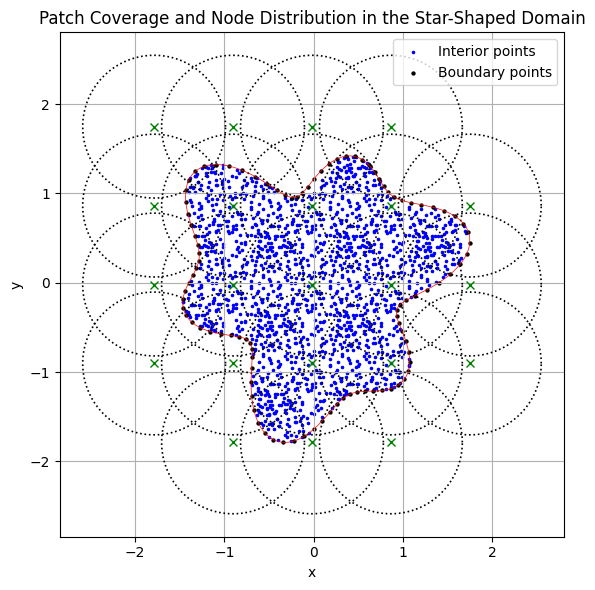

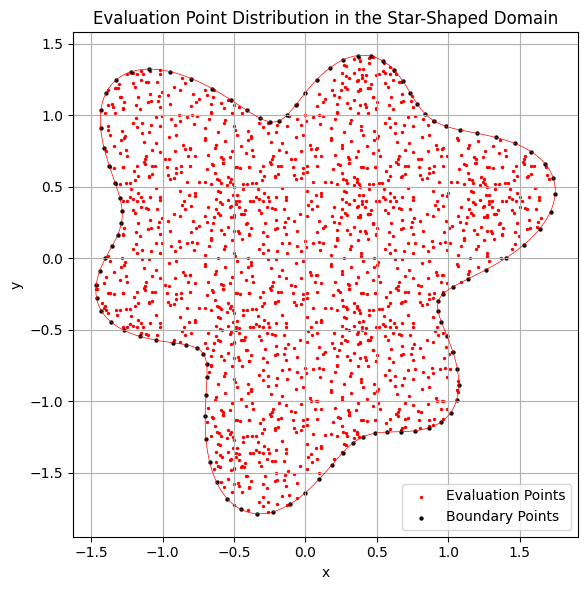

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def vandercorput(n, base):
    """
    Vectorized van der Corput for n = array-like nonnegative integers and given base.
    Returns array of same shape as n with values in [0,1).
    """
    n = np.asarray(n, dtype=np.int64)
    # compute digits for each n by repeated division
    out = np.zeros_like(n, dtype=np.float64)
    denom = base
    current = n.copy()
    while np.any(current > 0):
        digit = current % base
        out += digit / denom
        current = current // base
        denom *= base
    return out

def halton_sequence(N, dim):
    """
    Generate first N points of Halton sequence in `dim` dimensions.
    Uses first `dim` primes as bases.
    Returns array shape (N, dim) with values in [0,1).
    """
    # small prime list sufficient for moderate dim
    primes_list = [2, 3, 5, 7, 11, 13, 17, 19, 23, 29, 31, 37, 41, 43, 47, 53, 59]
    if dim > len(primes_list):
        raise ValueError("Requested dimension too large for built-in primes list.")
    bases = primes_list[:dim]
    n_idx = np.arange(0, N, dtype=np.int64)  # n = 0..N-1
    H = np.empty((N, dim), dtype=np.float64)
    for j, b in enumerate(bases):
        H[:, j] = vandercorput(n_idx, b)
    return H

def generator_points_star(N_patch_grid,
                     N_local_per_patch,
                     N_boundary,
                     R_ptch,
                     mode="c-rbf-pum"):
    """
    Generate points on a star-shaped region and patch covering.

    Parameters
    ----------
    N_patch_grid : int
        number of patches per dimension (grid)
    N_local_per_patch : int
        target local points per patch (used as halton sample size per patch)
    N_boundary : int
        number of boundary points
    R_ptch : float
        patch radius
    mode : str
        "c-rbf-pum" or "ls-rbf-pum"

    Returns
    -------
    X_inner : ndarray (N_x,2)
        concatenated interior/source points
    X_boundary : ndarray (N_boundary,2)
        boundary points (uniform in theta)
    ptch : dict
        {'C': array(P,2), 'R': array(P,) } patch centers and radii
    grid_eval : ndarray (N_eval,2)
        evaluation/prediction points (depends on mode)
    """
    # -------------------------
    # 1. star region radial function
    def r_max_func(theta):
        return 2.0 * (0.7 + 0.12 * (np.sin(6*theta) + np.sin(3*theta)))

    # vector theta for plotting / sampling
    theta_plot = np.linspace(0.0, 2*np.pi, 1000, endpoint=False)
    r_plot = r_max_func(theta_plot)
    x_plot = r_plot * np.cos(theta_plot)
    y_plot = r_plot * np.sin(theta_plot)

    x_min, x_max = x_plot.min(), x_plot.max()
    y_min, y_max = y_plot.min(), y_plot.max()
    R_container = r_plot.max()

    # helper: is point(s) inside star region (vectorized)
    def is_inside_star(x, y):
        x = np.asarray(x)
        y = np.asarray(y)
        r = np.sqrt(x**2 + y**2)
        theta = np.arctan2(y, x)
        theta = np.where(theta < 0, theta + 2*np.pi, theta)
        r_limit = r_max_func(theta)
        TOL = 1e-12
        return r <= (r_limit + TOL)

    # -------------------------
    # 2. Patch grid parameters
    Domain_size = max(x_max - x_min, y_max - y_min)
    num_patches_1D = int(N_patch_grid)
    # avoid division by zero when Domain_size small
    if num_patches_1D <= 1:
        del_param = 0.0
    else:
        del_param = (num_patches_1D - Domain_size / R_ptch) / (num_patches_1D - 1)
    patch_spacing = 2 * R_ptch * (1 - del_param)

    # create center grid in bounding square [Grid_min, Grid_max]^2
    Grid_min = min(x_min, y_min)
    Grid_max = max(x_max, y_max)
    Cx = np.linspace(Grid_min, Grid_max, num_patches_1D)
    Cy = np.linspace(Grid_min, Grid_max, num_patches_1D)
    Cxv, Cyv = np.meshgrid(Cx, Cy)
    C_all = np.column_stack([Cxv.ravel(), Cyv.ravel()])
    R_all = R_ptch * np.ones((C_all.shape[0],), dtype=np.float64)

    # For each candidate patch, sample its circle boundary points and check overlap
    theta_circ = theta_plot  # reuse dense sample
    # build for all centers: shifted circle coordinates
    # shape (num_centers, n_theta)
    bc_x = C_all[:, 0:1] + R_all[:, None] * np.cos(theta_circ)[None, :]
    bc_y = C_all[:, 1:] + R_all[:, None] * np.sin(theta_circ)[None, :]

    # Determine which patch has any boundary point inside the star region
    # is_inside_star accepts arrays; compute over all boundary samples
    inside_flags = is_inside_star(bc_x, bc_y)  # shape (num_centers, n_theta)
    id_keep = np.where(inside_flags.sum(axis=1) > 0)[0]

    C_kept = C_all[id_keep, :]
    R_kept = R_all[id_keep]
    ptch = {'C': C_kept, 'R': R_kept}
    P = C_kept.shape[0]

    # -------------------------
    # 3. Generate RBF center points per patch (Halton sampling in polar coords)
    X_inner_points = []
    grid_eval_points = []  # for c-rbf-pum mode
    # we will use exactly N_local_per_patch halton samples per patch (as in your adjusted code)
    N_generate = int(N_local_per_patch)
    # for LS mode, generate global evaluation grid if requested
    if mode == "ls-rbf-pum":
        # create a dense grid that covers the bounding box and then trim to star region
        n_grid = int(round(np.sqrt(P * N_generate) * 1.5))
        if n_grid < 2:
            n_grid = 2
        x_eval = np.linspace(x_min, x_max, n_grid)
        y_eval = np.linspace(y_min, y_max, n_grid)
        Xg, Yg = np.meshgrid(x_eval, y_eval)
        grid_pts = np.column_stack([Xg.ravel(), Yg.ravel()])
        mask_grid = is_inside_star(grid_pts[:, 0], grid_pts[:, 1])
        grid_eval_all = grid_pts[mask_grid, :]
    else:
        grid_eval_all = np.empty((0, 2))

    # Halton base samples for polar mapping (u,v)
    H = halton_sequence(N_generate, 2)  # (N_generate, 2)
    u = H[:, 0]
    v = H[:, 1]

    for i in range(P):
        C = C_kept[i, :]
        R = R_kept[i]
        theta_local = 2.0 * np.pi * u  # (N_generate,)
        r_local = np.sqrt(v) * R
        x_local = r_local * np.cos(theta_local) + C[0]
        y_local = r_local * np.sin(theta_local) + C[1]
        if mode == "c-rbf-pum":
            inside_mask = is_inside_star(x_local, y_local)
            X_candidate = np.column_stack([x_local[inside_mask], y_local[inside_mask]])
            # keep all that are inside; you may trim to desired count elsewhere
            X_inner_points.append(X_candidate)
            grid_eval_points.append(X_candidate)
        elif mode == "ls-rbf-pum":
            # do not clip to patch by star region (as MATLAB's ls mode keeps all)
            X_candidate = np.column_stack([x_local, y_local])
            X_inner_points.append(X_candidate)
            # N_total in MATLAB set to P * N_generate; we follow that
        else:
            raise ValueError("Unrecognized mode: {}".format(mode))

    if len(X_inner_points) > 0:
        X_inner = np.vstack([arr for arr in X_inner_points if arr.shape[0] > 0])
    else:
        X_inner = np.empty((0, 2))

    if mode == "c-rbf-pum":
        # grid_eval collects retained candidates
        if len(grid_eval_points) > 0:
            grid_eval = np.vstack([arr for arr in grid_eval_points if arr.shape[0] > 0])
        else:
            grid_eval = np.empty((0, 2))
    else:
        grid_eval = grid_eval_all

    # -------------------------
    # 4. Generate boundary points (uniform in theta)
    theta_bnd = np.linspace(0.0, 2*np.pi, N_boundary, endpoint=False)
    r_bnd = r_max_func(theta_bnd)
    x_bnd = r_bnd * np.cos(theta_bnd)
    y_bnd = r_bnd * np.sin(theta_bnd)
    X_boundary = np.column_stack([x_bnd, y_bnd])

    # also return boundary curve for plotting convenience
    boundary_curve = np.column_stack([x_plot, y_plot])

    return X_inner, X_boundary, ptch, grid_eval, boundary_curve

# --------------------------
# Plotting wrapper
# --------------------------
def plot_generator_points(X_inner, X_boundary, ptch, grid_eval, boundary_curve, figsize1=(7,6), figsize2=(7,6)):
    """
    Draw two figures similar to MATLAB version:
    - Figure 1: patch coverage, interior points, boundary points, region boundary
    - Figure 2: prediction grid and boundary
    """
    C = ptch['C']
    R = ptch['R']
    P = C.shape[0]
    theta_circ = np.linspace(0, 2*np.pi, 200)

    # Figure 1
    plt.figure(figsize=figsize1)
    ax = plt.gca()
    # patch circles (dashed)
    for i in range(P):
        x_circ = C[i,0] + R[i] * np.cos(theta_circ)
        y_circ = C[i,1] + R[i] * np.sin(theta_circ)
        ax.plot(x_circ, y_circ, linestyle=':', color='k', linewidth=1.2)
        ax.plot(C[i,0], C[i,1], marker='x', color='g', markersize=6)
    # region boundary
    ax.plot(boundary_curve[:,0], boundary_curve[:,1], 'r-', linewidth=0.5)
    # interior points
    if X_inner.shape[0] > 0:
        ax.scatter(X_inner[:,0], X_inner[:,1], s=10, c='b', marker='.', label='Interior points')
    # boundary points
    if X_boundary.shape[0] > 0:
        ax.scatter(X_boundary[:,0], X_boundary[:,1], s=18, c='k', marker='.', label='Boundary points')
    ax.set_aspect('equal', 'box')
    ax.set_title('Patch Coverage and Node Distribution in the Star-Shaped Domain', fontsize=12)
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.legend()
    ax.grid(True)
    plt.tight_layout()

    # Figure 2: prediction grid
    plt.figure(figsize=figsize2)
    ax2 = plt.gca()
    ax2.plot(boundary_curve[:,0], boundary_curve[:,1], 'r-', linewidth=0.5)
    if grid_eval is not None and grid_eval.shape[0] > 0:
        ax2.scatter(grid_eval[:,0], grid_eval[:,1], s=8, c='r', marker='.', label='Evaluation Points')
    if X_boundary.shape[0] > 0:
        ax2.scatter(X_boundary[:,0], X_boundary[:,1], s=18, c='k', marker='.', label='Boundary Points')
    ax2.set_aspect('equal', 'box')
    ax2.set_title('Evaluation Point Distribution in the Star-Shaped Domain', fontsize=12)
    ax2.set_xlabel('x')
    ax2.set_ylabel('y')
    ax2.legend()
    ax2.grid(True)
    plt.tight_layout()

    plt.show()


# ============================
# Example usage
# ============================
if __name__ == "__main__":
    # parameters (same defaults as your MATLAB example)
    N_patch_grid = 5
    N_local_per_patch = 200
    N_boundary = 100
    R_ptch = 0.8
    mode = "c-rbf-pum"  # or "ls-rbf-pum"

    X_inner, X_boundary, ptch, grid_eval, boundary_curve = generator_points_star(
        N_patch_grid, N_local_per_patch, N_boundary, R_ptch, mode
    )

    print("生成内部点数:", X_inner.shape[0])
    print("生成边界点数:", X_boundary.shape[0])
    print("Patch 数量:", ptch['C'].shape[0])
    print("预测点数:", grid_eval.shape[0])

    # 绘图
    plot_generator_points(X_inner, X_boundary, ptch, grid_eval, boundary_curve)

X.shape: (1823, 2)
L infity error in u: 4.163e-04
Relative L2 error in u: 1.470e-04


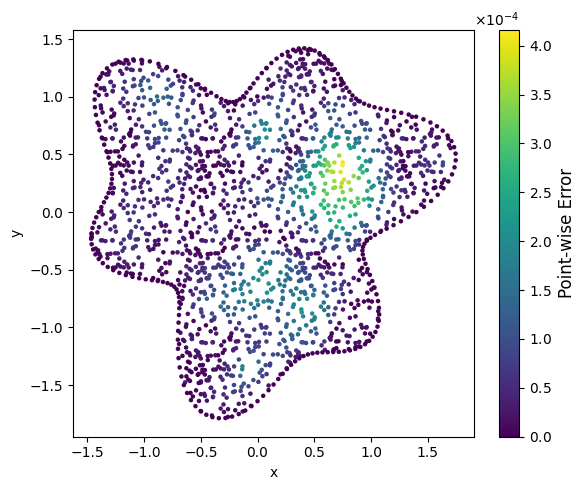

In [2]:
import torch
from scipy.io import loadmat
import numpy as np
import matplotlib.pyplot as plt
import torch.nn as nn
from scipy.spatial import cKDTree, distance
from scipy.linalg import cholesky
from scipy.sparse import lil_matrix
from scipy.sparse.linalg import spsolve, lsqr
import matplotlib.pyplot as plt

dtype = torch.float64
device = torch.device('cuda:1' if torch.cuda.is_available() else 'cpu')

def relative_loss(predict, exact):
    error = torch.sqrt(torch.sum((predict - exact) ** 2)) / torch.sqrt(torch.sum((exact) ** 2))
    return error

def vandercorput(n, base):
    """
    Vectorized van der Corput for n = array-like nonnegative integers and given base.
    Returns array of same shape as n with values in [0,1).
    """
    n = np.asarray(n, dtype=np.int64)
    # compute digits for each n by repeated division
    out = np.zeros_like(n, dtype=np.float64)
    denom = base
    current = n.copy()
    while np.any(current > 0):
        digit = current % base
        out += digit / denom
        current = current // base
        denom *= base
    return out

def halton_sequence(N, dim):
    """
    Generate first N points of Halton sequence in `dim` dimensions.
    Uses first `dim` primes as bases.
    Returns array shape (N, dim) with values in [0,1).
    """
    # small prime list sufficient for moderate dim
    primes_list = [2, 3, 5, 7, 11, 13, 17, 19, 23, 29, 31, 37, 41, 43, 47, 53, 59]
    if dim > len(primes_list):
        raise ValueError("Requested dimension too large for built-in primes list.")
    bases = primes_list[:dim]
    n_idx = np.arange(0, N, dtype=np.int64)  # n = 0..N-1
    H = np.empty((N, dim), dtype=np.float64)
    for j, b in enumerate(bases):
        H[:, j] = vandercorput(n_idx, b)
    return H

def generator_points_star(N_patch_grid,
                     N_local_per_patch,
                     N_boundary,
                     R_ptch,
                     mode="c-rbf-pum"):
    """
    Generate points on a star-shaped region and patch covering.

    Parameters
    ----------
    N_patch_grid : int
        number of patches per dimension (grid)
    N_local_per_patch : int
        target local points per patch (used as halton sample size per patch)
    N_boundary : int
        number of boundary points
    R_ptch : float
        patch radius
    mode : str
        "c-rbf-pum" or "ls-rbf-pum"

    Returns
    -------
    X_inner : ndarray (N_x,2)
        concatenated interior/source points
    X_boundary : ndarray (N_boundary,2)
        boundary points (uniform in theta)
    ptch : dict
        {'C': array(P,2), 'R': array(P,) } patch centers and radii
    grid_eval : ndarray (N_eval,2)
        evaluation/prediction points (depends on mode)
    """
    # -------------------------
    # 1. star region radial function
    def r_max_func(theta):
        return 2.0 * (0.7 + 0.12 * (np.sin(6*theta) + np.sin(3*theta)))

    # vector theta for plotting / sampling
    theta_plot = np.linspace(0.0, 2*np.pi, 1000, endpoint=False)
    r_plot = r_max_func(theta_plot)
    x_plot = r_plot * np.cos(theta_plot)
    y_plot = r_plot * np.sin(theta_plot)

    x_min, x_max = x_plot.min(), x_plot.max()
    y_min, y_max = y_plot.min(), y_plot.max()
    R_container = r_plot.max()

    # helper: is point(s) inside star region (vectorized)
    def is_inside_star(x, y):
        x = np.asarray(x)
        y = np.asarray(y)
        r = np.sqrt(x**2 + y**2)
        theta = np.arctan2(y, x)
        theta = np.where(theta < 0, theta + 2*np.pi, theta)
        r_limit = r_max_func(theta)
        TOL = 1e-12
        return r <= (r_limit + TOL)

    # -------------------------
    # 2. Patch grid parameters
    Domain_size = max(x_max - x_min, y_max - y_min)
    num_patches_1D = int(N_patch_grid)
    # avoid division by zero when Domain_size small
    if num_patches_1D <= 1:
        del_param = 0.0
    else:
        del_param = (num_patches_1D - Domain_size / R_ptch) / (num_patches_1D - 1)
    patch_spacing = 2 * R_ptch * (1 - del_param)

    # create center grid in bounding square [Grid_min, Grid_max]^2
    Grid_min = min(x_min, y_min)
    Grid_max = max(x_max, y_max)
    Cx = np.linspace(Grid_min, Grid_max, num_patches_1D)
    Cy = np.linspace(Grid_min, Grid_max, num_patches_1D)
    Cxv, Cyv = np.meshgrid(Cx, Cy)
    C_all = np.column_stack([Cxv.ravel(), Cyv.ravel()])
    R_all = R_ptch * np.ones((C_all.shape[0],), dtype=np.float64)

    # For each candidate patch, sample its circle boundary points and check overlap
    theta_circ = theta_plot  # reuse dense sample
    # build for all centers: shifted circle coordinates
    # shape (num_centers, n_theta)
    bc_x = C_all[:, 0:1] + R_all[:, None] * np.cos(theta_circ)[None, :]
    bc_y = C_all[:, 1:] + R_all[:, None] * np.sin(theta_circ)[None, :]

    # Determine which patch has any boundary point inside the star region
    # is_inside_star accepts arrays; compute over all boundary samples
    inside_flags = is_inside_star(bc_x, bc_y)  # shape (num_centers, n_theta)
    id_keep = np.where(inside_flags.sum(axis=1) > 0)[0]

    C_kept = C_all[id_keep, :]
    R_kept = R_all[id_keep]
    ptch = {'C': C_kept, 'R': R_kept}
    P = C_kept.shape[0]

    # -------------------------
    # 3. Generate RBF center points per patch (Halton sampling in polar coords)
    X_inner_points = []
    grid_eval_points = []  # for c-rbf-pum mode
    # we will use exactly N_local_per_patch halton samples per patch (as in your adjusted code)
    N_generate = int(N_local_per_patch)
    # for LS mode, generate global evaluation grid if requested
    if mode == "ls-rbf-pum":
        # create a dense grid that covers the bounding box and then trim to star region
        n_grid = int(round(np.sqrt(P * N_generate) * 1.5))
        if n_grid < 2:
            n_grid = 2
        x_eval = np.linspace(x_min, x_max, n_grid)
        y_eval = np.linspace(y_min, y_max, n_grid)
        Xg, Yg = np.meshgrid(x_eval, y_eval)
        grid_pts = np.column_stack([Xg.ravel(), Yg.ravel()])
        mask_grid = is_inside_star(grid_pts[:, 0], grid_pts[:, 1])
        grid_eval_all = grid_pts[mask_grid, :]
    else:
        grid_eval_all = np.empty((0, 2))

    # Halton base samples for polar mapping (u,v)
    H = halton_sequence(N_generate, 2)  # (N_generate, 2)
    u = H[:, 0]
    v = H[:, 1]

    for i in range(P):
        C = C_kept[i, :]
        R = R_kept[i]
        theta_local = 2.0 * np.pi * u  # (N_generate,)
        r_local = np.sqrt(v) * R
        x_local = r_local * np.cos(theta_local) + C[0]
        y_local = r_local * np.sin(theta_local) + C[1]
        if mode == "c-rbf-pum":
            inside_mask = is_inside_star(x_local, y_local)
            X_candidate = np.column_stack([x_local[inside_mask], y_local[inside_mask]])
            # keep all that are inside; you may trim to desired count elsewhere
            X_inner_points.append(X_candidate)
            grid_eval_points.append(X_candidate)
        elif mode == "ls-rbf-pum":
            # do not clip to patch by star region (as MATLAB's ls mode keeps all)
            X_candidate = np.column_stack([x_local, y_local])
            X_inner_points.append(X_candidate)
            # N_total in MATLAB set to P * N_generate; we follow that
        else:
            raise ValueError("Unrecognized mode: {}".format(mode))

    if len(X_inner_points) > 0:
        X_inner = np.vstack([arr for arr in X_inner_points if arr.shape[0] > 0])
    else:
        X_inner = np.empty((0, 2))

    if mode == "c-rbf-pum":
        # grid_eval collects retained candidates
        if len(grid_eval_points) > 0:
            grid_eval = np.vstack([arr for arr in grid_eval_points if arr.shape[0] > 0])
        else:
            grid_eval = np.empty((0, 2))
    else:
        grid_eval = grid_eval_all

    # -------------------------
    # 4. Generate boundary points (uniform in theta)
    theta_bnd = np.linspace(0.0, 2*np.pi, N_boundary, endpoint=False)
    r_bnd = r_max_func(theta_bnd)
    x_bnd = r_bnd * np.cos(theta_bnd)
    y_bnd = r_bnd * np.sin(theta_bnd)
    X_boundary = np.column_stack([x_bnd, y_bnd])

    # also return boundary curve for plotting convenience
    boundary_curve = np.column_stack([x_plot, y_plot])

    return X_inner, X_boundary, ptch, grid_eval, boundary_curve

# --------------------------
# Plotting wrapper
# --------------------------
def plot_generator_points(X_inner, X_boundary, ptch, grid_eval, boundary_curve, figsize1=(7,6), figsize2=(7,6)):
    """
    Draw two figures similar to MATLAB version:
    - Figure 1: patch coverage, interior points, boundary points, region boundary
    - Figure 2: prediction grid and boundary
    """
    C = ptch['C']
    R = ptch['R']
    P = C.shape[0]
    theta_circ = np.linspace(0, 2*np.pi, 200)

    # Figure 1
    plt.figure(figsize=figsize1)
    ax = plt.gca()
    # patch circles (dashed)
    for i in range(P):
        x_circ = C[i,0] + R[i] * np.cos(theta_circ)
        y_circ = C[i,1] + R[i] * np.sin(theta_circ)
        ax.plot(x_circ, y_circ, linestyle=':', color='k', linewidth=1.2)
        ax.plot(C[i,0], C[i,1], marker='x', color='g', markersize=6)
    # region boundary
    ax.plot(boundary_curve[:,0], boundary_curve[:,1], 'r-', linewidth=0.5)
    # interior points
    if X_inner.shape[0] > 0:
        ax.scatter(X_inner[:,0], X_inner[:,1], s=10, c='b', marker='.', label='Interior points')
    # boundary points
    if X_boundary.shape[0] > 0:
        ax.scatter(X_boundary[:,0], X_boundary[:,1], s=18, c='k', marker='.', label='Boundary points')
    ax.set_aspect('equal', 'box')
    ax.set_title('Patch Coverage and Node Distribution in the Star-Shaped Domain', fontsize=12)
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.legend()
    ax.grid(True)
    plt.tight_layout()

    # Figure 2: prediction grid
    plt.figure(figsize=figsize2)
    ax2 = plt.gca()
    ax2.plot(boundary_curve[:,0], boundary_curve[:,1], 'r-', linewidth=0.5)
    if grid_eval is not None and grid_eval.shape[0] > 0:
        ax2.scatter(grid_eval[:,0], grid_eval[:,1], s=8, c='r', marker='.', label='Evaluation Points')
    if X_boundary.shape[0] > 0:
        ax2.scatter(X_boundary[:,0], X_boundary[:,1], s=18, c='k', marker='.', label='Boundary Points')
    ax2.set_aspect('equal', 'box')
    ax2.set_title('Evaluation Point Distribution in the Star-Shaped Domain', fontsize=12)
    ax2.set_xlabel('x')
    ax2.set_ylabel('y')
    ax2.legend()
    ax2.grid(True)
    plt.tight_layout()
    plt.show()



def laplacian_phi_wrt_y(phi_net, y, X, eps=1e-8):
    """
    y: tensor (1,2) evalution points, requires_grad = True
    X: tensor (K,2) source points
    Returns: phi_vals (K,1), laplacian_y (K,1), grad_y (K,2)
    """
    y = torch.tensor(y, dtype=torch.float64, device=device)
    X = torch.tensor(X, dtype=torch.float64, device=device)
    if y.dim()==1:
        y = y.unsqueeze(0)   # (1,2)
    K = X.shape[0]
    # compute r_j
    diff = y - X          # (K,2) if y (1,2)
    r = torch.norm(diff, dim=1, keepdim=True)   # (K,1)
    r = r.clamp(min=eps)  # 防止除零

    r.requires_grad_(True)    # 需要对 r 求导
    phi_vals = phi_net(r)     # (K,1)
    # phi_vals = phi_gauss(eps,r) # to check whether the laplace using autograd is correct

    # phi'(r)
    dphi_dr = torch.autograd.grad(
        outputs=phi_vals,
        inputs=r,
        grad_outputs=torch.ones_like(phi_vals),
        create_graph=True,
        retain_graph=True,
    )[0]   # (K,1)

    # phi''(r)
    d2phi_dr2 = torch.autograd.grad(
        outputs=dphi_dr,
        inputs=r,
        grad_outputs=torch.ones_like(dphi_dr),
        create_graph=False,
        retain_graph=True
    )[0]   # (K,1)

    n = y.shape[1]  # dimension, n = 2 here
    lap_r = d2phi_dr2 + (n-1)/r * dphi_dr   # (K,1),
    # print("relative error between  is",relative_loss(lap_r, laplace_phi_gauss(eps, r)))
    # 一阶向量梯度 wrt y： ∇_y φ = φ'(r) * (y - x)/r
    grad_y = dphi_dr * (diff / r)    # broadcasting (K,2): (grad_y1,grad_y2) 
    phi_vals = phi_vals.detach().cpu().numpy()
    lap_r = lap_r.detach().cpu().numpy()
    grad_y = grad_y.detach().cpu().numpy()
    return phi_vals, lap_r, grad_y


def rfm_fd_poly_solve_poisson_nn(X, Yin, Yb, f_func, g_func, Phi, K, reg, order):
    """
    X:  (N,2)  RBF source points
    Yin: (M1,2) interior points
    Yb:  (M2,2) boundary points
    f_func, g_func: Python callable returning torch tensor
    K: number of neighbors
    order: polynomial order (1,2,3,...)
    """
    Norder = (order + 1) * (order + 2) // 2  # number of polynomial basis in 2D
    # Combine evaluation points
    Y = np.concatenate([Yin, Yb], axis=0)
    # Compute distance to all source points
    M = Y.shape[0]
    N = X.shape[0]
    M2 = Yb.shape[0] # number of boundary points
    M1 = M - M2

    tree = cKDTree(X)
    dist, idx = tree.query(Y, k=K, workers=-1)  # (M,K)

    # Construct sparse L matrix
    L = lil_matrix((M, N))
    W_ide = np.zeros((M, K+Norder))
    W_lap = np.zeros((M, K+Norder))
    # Construct RHS
    RHS = np.zeros((M,1))
    if callable(f_func):
        RHS[:M1,0:1] = f_func(Yin[:,0:1], Yin[:,1:2])
    elif isinstance(f_func, np.ndarray):
        RHS[:M1,:] = f_func[:,None] # (M1,1)
    else:
        raise ValueError("f_func must be callable or numpy array")
    if callable(g_func):
        RHS[-M2:,0:1] = g_func(Yb[:,0:1], Yb[:,1:2])
    elif isinstance(g_func, np.ndarray):
        RHS[-M2:,:] = g_func[:,None] # (M2,1)
    else:
        raise ValueError("g_func must be callable or numpy array")

    O = np.zeros((Norder,Norder))

    for i in range(M):
        RHS_lap = np.zeros((K+Norder,1))
        RHS_ide = np.ones((K+Norder,1))
        AP = np.zeros((K+Norder,K+Norder))
        P = np.ones((K,Norder))
        y = Y[i,:] # (2,)
        idx_local = idx[i,:]    # (K,)
        Z = X[idx_local]       # (K,2)
        dist_ZZ = distance.cdist(Z, Z, metric='euclidean') # (K,K)
        dist_ZZ = torch.as_tensor(dist_ZZ, dtype = torch.float64, device = device)
        Phi_jj = Phi(dist_ZZ) # (K,K)
        Phi_jj = Phi_jj.detach().cpu().numpy()
        phi_xj, lap_phi, _  = laplacian_phi_wrt_y(Phi, y, Z, eps=1e-8) # (K,1)

        ## W_ide
        def poly2D(Z, order):
            K = Z.shape[0]
            Norder = (order+1)*(order+2)//2
            P = np.zeros((K, Norder))
            idx = 0
            for i in range(order+1):
                for j in range(order+1-i):
                    P[:, idx] = (Z[:,0]**i) * (Z[:,1]**j)
                    idx += 1
            return P
        P = poly2D(Z, order)  # (K,Norder)
        AP[:K,:] = np.concatenate([Phi_jj,P], axis = 1) # (K,K+3)
        AP[K:,:-Norder] = P.T # (6,K)
        ## W_ide, RHS_ide
        def poly2D_at_point(y, order):
            """Generate column vector of poly basis at single point y (2D)"""
            Norder = (order+1)*(order+2)//2
            p_y = np.zeros((Norder,1))
            idx = 0
            for i in range(order+1):
                for j in range(order+1-i):
                    p_y[idx,0] = (y[0]**i) * (y[1]**j)
                    idx += 1
            return p_y
        p_y = poly2D_at_point(y, order)  # (Norder,1)
        RHS_ide[:K,0] = phi_xj[:,0]                           # shape (K,)
        RHS_ide[K:,0] = p_y[:,0]
        AP = AP + reg * np.eye(K+Norder)
        w_ide = np.linalg.solve(AP,RHS_ide).T # (1,K+3)
        W_ide[i:i+1,:] = w_ide
        ## W_lap
        # Laplace weights: laplace_phi = Phi_jj w_lap
        def laplacian_poly2D(order, y):
            """
            y: (2,) point
            return: column vector (Norder,1) of Laplacian evaluated at y
            """
            Norder = (order+1)*(order+2)//2
            lap = np.zeros((Norder,1))
            idx = 0
            for i in range(order+1):
                for j in range(order+1-i):
                    val = 0.0
                    if i >= 2:
                        val += i*(i-1)*y[0]**(i-2) * y[1]**j
                    if j >= 2:
                        val += j*(j-1)*y[0]**i * y[1]**(j-2)
                    lap[idx,0] = val
                    idx += 1
            return lap
        RHS_lap[:K,0] = lap_phi[:,0]
        RHS_lap[K:,0] = laplacian_poly2D(order, y)[:,0]
        w_lap = np.linalg.solve(AP,RHS_lap).T # (1,K+Noder)
        W_lap[i:i+1,:] = w_lap

        L[i, idx_local] = - w_lap[:,:K] if i < M1 else w_ide[:,:K]
    # ===========================================================
    # Solve linear system L U = RHS
    # ===========================================================
    L1 = L.tocsr()
    if M == N:
        UX = spsolve(L1, RHS)
    else:
        Q, R = np.linalg.qr(L1.toarray(), mode='reduced')
        UX = np.linalg.solve(R, Q.T @ RHS)

    # ===========================================================
    # Evaluate solution at Y
    # ===========================================================
    LL = lil_matrix((M, N),dtype=np.float64)
    for i in range(M):
        idx_local = idx[i,:]    # (K,)
        LL[i,idx_local] = LL[i,idx_local] + W_ide[i,:K]
    LL = LL.tocsr()
    UY = LL.dot(UX).reshape(-1,1)
    return UY,L,LL

# # ===========================================================
# # Evaluate solution at Y
# # ===========================================================
def test(idx,W_ide,L,f_func,u_func,Yin,Yb):
    """
    Yin: (M1,2) interior points
    Yb:  (M2,2) boundary points
    f_func, u_func: Python callable returning torch tensor
    idx: X in Y' kdtree
    """
    M,N = L.shape[0],L.shape[1]
    M1,M2 = Yin.shape[0],Yb.shape[0]
    RHS = np.zeros((M,1))
    if callable(f_func):
        RHS[:M1,0:1] = f_func(Yin[:,0:1], Yin[:,1:2])
    elif isinstance(f_func, np.ndarray):
        RHS[:M1,:] = f_func[:,None] # (M1,1)
    else:
        raise ValueError("f_func must be callable or numpy array")
    if callable(g_func):
        RHS[-M2:,0:1] = u_func(Yb[:,0:1], Yb[:,1:2])
    elif isinstance(g_func, np.ndarray):
        RHS[-M2:,:] = g_func[:,None] # (M2,1)
    else:
        raise ValueError("g_func must be callable or numpy array")
    L1 = L.tocsr()
    if M == N:
        UX = spsolve(L1, RHS)
    else:
        Q, R = np.linalg.qr(L1.toarray(), mode='reduced')
        UX = np.linalg.solve(R, Q.T @ RHS)

    LL = lil_matrix((M, N),dtype=np.float64)
    for i in range(M):
        idx_local = idx[i,:]    # (K,)
        LL[i,idx_local] = LL[i,idx_local] + W_ide[i,:K]
    LL = LL.tocsr()
    UY = LL.dot(UX).reshape(-1,1)
    return UY

def rfm_fd_solve_poisson_nn(X, Yin, Yb, f_func, g_func, Phi, K, reg):
    """
    X:  (N,2)  RBF source points
    Yin: (M1,2) interior points
    Yb:  (M2,2) boundary points
    f_func, g_func: Python callable returning torch tensor
    K: number of neighbors
    order: 0
    """
    # Combine evaluation points
    Y = np.concatenate([Yin, Yb], axis=0)
    # Compute distance to all source points
    M = Y.shape[0]
    N = X.shape[0]
    M2 = Yb.shape[0] # number of boundary points
    M1 = M - M2

    tree = cKDTree(X)
    dist, idx = tree.query(Y, k=K, workers=-1)  # (M,K)

    # Construct sparse L matrix
    L = lil_matrix((M, N))
    W_ide = np.zeros((M, K))
    W_lap = np.zeros((M, K))
    # Construct RHS
    RHS = np.zeros((M,1))
    if callable(f_func):
        RHS[:M1,0:1] = f_func(Yin[:,0:1], Yin[:,1:2])
    elif isinstance(f_func, np.ndarray):
        RHS[:M1,:] = f_func[:,None] # (M1,1)
    else:
        raise ValueError("f_func must be callable or numpy array")
    if callable(g_func):
        RHS[-M2:,0:1] = g_func(Yb[:,0:1], Yb[:,1:2])
    elif isinstance(g_func, np.ndarray):
        RHS[-M2:,:] = g_func[:,None] # (M2,1)
    else:
        raise ValueError("g_func must be callable or numpy array")

    for i in range(M):
        RHS_lap = np.zeros((K,1))
        RHS_ide = np.ones((K,1))
        A = np.zeros((K,K))
        y = Y[i,:] # (2,)
        idx_local = idx[i,:]    # (K,)
        Z = X[idx_local]       # (K,2)
        dist_ZZ = distance.cdist(Z, Z, metric='euclidean') # (K,K)
        dist_ZZ = torch.as_tensor(dist_ZZ, dtype = torch.float64, device = device)
        Phi_jj = Phi(dist_ZZ) # (K,K)
        Phi_jj = Phi_jj.detach().cpu().numpy()
        phi_xj, lap_phi, _  = laplacian_phi_wrt_y(Phi, y, Z, eps=1e-8) # (K,1)
        ## RHS_lap, RHS_ide
        RHS_lap = lap_phi
        RHS_ide = phi_xj
        ## W_ide, W_lap
        A  =  Phi_jj  + reg * np.eye(K) # (K,K)
        w_ide = np.linalg.solve(A,RHS_ide).T # (1,K+3)
        W_ide[i:i+1,:] = w_ide
        w_lap = np.linalg.solve(A,RHS_lap).T # (1,K+Noder)
        W_lap[i:i+1,:] = w_lap
        L[i, idx_local] = - w_lap if i < M1 else w_ide
    # ===========================================================
    # Solve linear system L U = RHS
    # ===========================================================
    L1 = L.tocsr()
    if M == N:
        UX = spsolve(L1, RHS)
    else:
        Q, R = np.linalg.qr(L1.toarray(), mode='reduced')
        UX = np.linalg.solve(R, Q.T @ RHS)

    # ===========================================================
    # Evaluate solution at Y
    # ===========================================================
    LL = lil_matrix((M, N),dtype=np.float64)
    for i in range(M):
        idx_local = idx[i,:]    # (K,)
        LL[i,idx_local] = LL[i,idx_local] + W_ide[i,:]
    LL = LL.tocsr()
    UY = LL.dot(UX).reshape(-1,1)
    return UY,L,LL


def fill_distance(nodes):
    """
    nodes: (N, d) numpy array
    returns: scalar h = max_i min_{j != i} ||x_i - x_j||
    """
    nodes = np.asarray(nodes)
    if nodes.shape[0] <= 1:
        return 0.0
    tree = cKDTree(nodes)
    # query 2 nearest (including itself at dist 0), then take second column
    dists, _ = tree.query(nodes, k=2, workers=-1)
    # dists[:,0] == 0, so use dists[:,1]
    min_neigh = dists[:, 1]
    return np.float64(np.max(min_neigh))


class PhiNet(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(PhiNet, self).__init__()
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.output_size = output_size
        self.input_layer = nn.Linear(input_size, hidden_size, bias = True)
        self.hidden_layer = nn.Linear(hidden_size, hidden_size, bias = True)
        self.output_layer = nn.Linear(hidden_size, output_size, bias = None) 
	
    def forward(self, x): # r : (K,1)  or (K,K)
        K = x.shape[0]
        if x.shape[-1] != self.input_size:
            x = x.view(-1, self.input_size)
        output = self.input_layer(x)
        output = torch.sin(output)
        output = torch.cos(self.hidden_layer(output))
        output = self.output_layer(output)
        if output.shape[0] != K:
            output = output.view(K, -1)
        return output
	
    def initi(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight.data)
                if m.bias is not None:
                    # nn.init.normal_(m.bias, mean=0.0, std=1)
                    m.bias.data.zero_()

key = 100
np.random.seed(key)
torch.manual_seed(key)
torch.cuda.manual_seed_all(key)

hidden_size = 10
Phi = PhiNet(input_size=1, hidden_size=hidden_size, output_size=1).to(device) #
Phi.initi()
Phi = Phi.double() 


u_func = lambda x, y: x * np.cos(y)
f_func = lambda x, y: 0 * np.cos(y) +  x * np.cos(y)
g_func = lambda x, y: x * np.cos(y)

# global_error_vmax = 1.936e-04
# global_error_vmin = 0


torchdtype = torch.float64
N_patch_grid = 5
N_local_per_patch = 200
N_boundary = 200
R_ptch = 0.8
mode = "c-rbf-pum"
# generate points
X_inner, X_boundary, _, _ , _ = generator_points_star(
N_patch_grid, N_local_per_patch, N_boundary, R_ptch, mode)
X = np.vstack([X_inner, X_boundary])
print("X.shape:", X.shape)
Yin = X_inner
Yb = X_boundary
Y = np.vstack([Yin, Yb])
K = 50
reg = 1e-12
order = 1
u_true = u_func(Y[:,0:1], Y[:,1:2])
# # ===========================================================
if order == 0:
    UY,_,_ = rfm_fd_solve_poisson_nn(X, Yin, Yb, f_func, g_func, Phi, K, reg)
else:
    UY,_,_= rfm_fd_poly_solve_poisson_nn(X, Yin, Yb, f_func, g_func, Phi, K, reg, order)
    
# print(u_true.shape,UY.shape)
error = np.abs(UY - u_true)#/np.abs(u_true + 1e-6)
# print(error)
print(f'L infity error in u: {error.max().item():.3e}')
error_u = np.linalg.norm(UY - u_true, 2) / np.linalg.norm(u_true, 2)
print(f'Relative L2 error in u: {error_u.item():.3e}')

import matplotlib.ticker as ticker
plt.figure(figsize=(6,5))
sc = plt.scatter(Y[:,0], Y[:,1], c=np.abs(UY - u_true), cmap='viridis', s=5,)
# sc = plt.scatter(Y[:,0], Y[:,1], c=np.abs(UY - u_true), cmap='viridis', s=5, vmin=global_error_vmin,
#     vmax=global_error_vmax)
cbar = plt.colorbar(sc)
cbar.set_label('Point-wise Error', fontsize=12)
formatter = ticker.ScalarFormatter(useMathText=True)
formatter.set_scientific(True)
formatter.set_powerlimits((0, 0))
cbar.ax.yaxis.set_major_formatter(formatter)
# plt.title(f'Augmented RFM-FD Point-wise Error (p = {order})')
plt.xlabel('x')
plt.ylabel('y')
plt.tight_layout()
# plt.savefig(f'./result/poisson2d_rfmfd_p={order}_error_200_xcos.eps', bbox_inches='tight')
plt.show()

##

# 画收敛阶段图

Run Q=1, N_local_per_patch=20
X.shape 183
h = 2.631e-01, L2 error = 4.545e-02
Run Q=2, N_local_per_patch=40
X.shape 366
h = 1.877e-01, L2 error = 2.114e-03
Run Q=3, N_local_per_patch=70
X.shape 644
h = 1.438e-01, L2 error = 2.188e-04
Run Q=4, N_local_per_patch=120
X.shape 1100
h = 1.020e-01, L2 error = 4.513e-05
Run Q=5, N_local_per_patch=200
X.shape 1823
h = 7.872e-02, L2 error = 5.370e-06
slope = 7.248677, bias = -2.693611


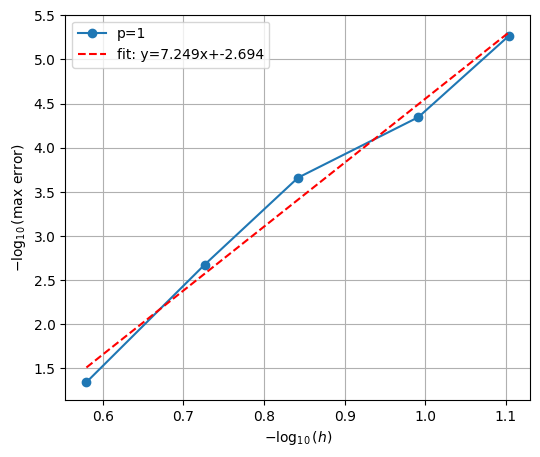

In [3]:
key = 100
np.random.seed(key)
H = np.zeros((4,5))
E = np.zeros((4,5))
NN = [20,40,70,120,200]
KK = [30,40,50,60,120]

RR = [1e-12,1e-12,1e-12,1e-13,1e-14]

for qi, n_local in enumerate(NN):
    print(f'Run Q={qi+1}, N_local_per_patch={n_local}')
    N_patch_grid = 5
    N_local_per_patch = n_local
    N_boundary = n_local
    R_ptch = 0.8
    mode = "c-rbf-pum"
    # generate points
    X_inner, X_boundary, _, _ ,_ = generator_points_star(
    N_patch_grid, N_local_per_patch, N_boundary, R_ptch, mode)
    # assemble X,Y
    X = np.vstack([X_inner, X_boundary])
    print(f"X.shape",X.shape[0])
    Yin = X_inner
    Yb = X_boundary
    Y = np.vstack([Yin, Yb])
    order = 0
    h = fill_distance(X)
    H[0,qi] = h
    reg = RR[qi]
    K = KK[qi]
    u_true = u_func(Y[:,0:1], Y[:,1:2])
    UY,_,_ = rfm_fd_solve_poisson_nn(X, Yin, Yb, f_func, g_func, Phi, K, reg)
    error = np.max(np.abs(UY - u_true))
    e = np.linalg.norm(UY - u_true)/np.linalg.norm(u_true)
    E[0,qi] = e
    print(f'h = {h:.3e}, L2 error = {e:.3e}')


x = -np.log10(H[0,:])
y = -np.log10(E[0,:])
mask = np.isfinite(x) & np.isfinite(y)
if np.count_nonzero(mask) >= 2:
    slope, intercept = np.polyfit(x[mask], y[mask], 1)
    print(f'slope = {slope:.6f}, bias = {intercept:.6f}')
    # 绘图并画出拟合直线
    xx = np.linspace(x[mask].min(), x[mask].max(), 100)
    yy = slope * xx + intercept
    plt.figure(figsize=(6,5))
    plt.plot(x, y, marker='o', linestyle='-', label='p=1')
    plt.plot(xx, yy, 'r--', label=f'fit: y={slope:.3f}x+{intercept:.3f}')
    # plt.plot(xx, yy, 'r--', label='')
    plt.xlabel(r'$- \log_{10}(h)$')
    plt.ylabel(r'$- \log_{10}(\mathrm{max\ error})$')
    plt.legend()
    plt.grid(True)
    # plt.title('p = 1, Convergence scatter and linear fitting ')
    # plt.savefig('./result/p=0_convergence_scatter_xcos.eps', bbox_inches='tight')
    plt.show()




Run Q=1, N_local_per_patch=20
X.shape 183
h = 2.631e-01, L2 error = 2.510e-02
Run Q=2, N_local_per_patch=40
X.shape 366
h = 1.877e-01, L2 error = 2.472e-03
Run Q=3, N_local_per_patch=70
X.shape 644
h = 1.438e-01, L2 error = 1.223e-04
Run Q=4, N_local_per_patch=120
X.shape 1100
h = 1.020e-01, L2 error = 2.032e-05
Run Q=5, N_local_per_patch=200
X.shape 1823
h = 7.872e-02, L2 error = 7.876e-06
slope = 6.926092, bias = -2.295286


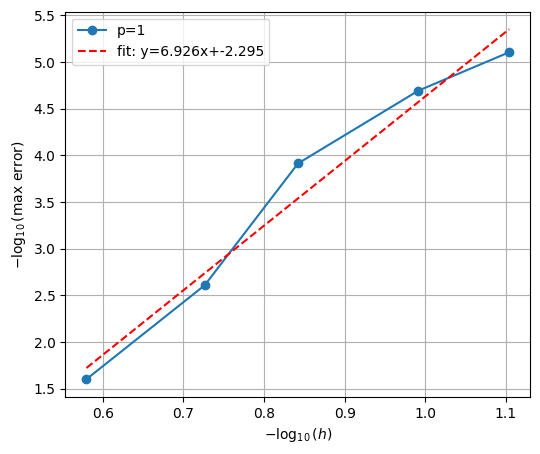

In [4]:
key = 100
np.random.seed(key)
NN = [20,40,70,120,200]
KK = [30,50,70,100,130]
RR = [1e-12,1e-12,1e-12,1e-13,1e-14]

# KK = [30,50,50,100,130]
# RR = [1e-12,1e-12,1e-12,1e-13,1e-14]


for qi, n_local in enumerate(NN):
    print(f'Run Q={qi+1}, N_local_per_patch={n_local}')
    N_patch_grid = 5
    N_local_per_patch = n_local
    N_boundary = n_local
    R_ptch = 0.8
    mode = "c-rbf-pum"
    # generate points
    X_inner, X_boundary, _, _ ,_ = generator_points_star(
    N_patch_grid, N_local_per_patch, N_boundary, R_ptch, mode)

    # assemble X,Y
    X = np.vstack([X_inner, X_boundary])
    print(f"X.shape",X.shape[0])
    Yin = X_inner
    Yb = X_boundary
    Y = np.vstack([Yin, Yb])
    order = 1
    h = fill_distance(X)
    H[order,qi] = h
    reg = RR[qi]
    K = KK[qi]
    
    u_true = u_func(Y[:,0:1], Y[:,1:2])
    UY,_,_ = rfm_fd_poly_solve_poisson_nn(X, Yin, Yb, f_func, g_func, Phi, K, reg, order)
    error = np.max(np.abs(UY - u_true))
    e = np.linalg.norm(UY - u_true)/np.linalg.norm(u_true)
    E[order,qi] = e
    print(f'h = {h:.3e}, L2 error = {e:.3e}')


x = -np.log10(H[order,:])
y = -np.log10(E[order,:])
mask = np.isfinite(x) & np.isfinite(y)
if np.count_nonzero(mask) >= 2:
    slope, intercept = np.polyfit(x[mask], y[mask], 1)
    print(f'slope = {slope:.6f}, bias = {intercept:.6f}')
    # 绘图并画出拟合直线
    xx = np.linspace(x[mask].min(), x[mask].max(), 100)
    yy = slope * xx + intercept
    plt.figure(figsize=(6,5))
    plt.plot(x, y, marker='o', linestyle='-', label=f'p={order}')
    plt.plot(xx, yy, 'r--', label=f'fit: y={slope:.3f}x+{intercept:.3f}')
    # plt.plot(xx, yy, 'r--', label='')
    plt.xlabel(r'$- \log_{10}(h)$')
    plt.ylabel(r'$- \log_{10}(\mathrm{max\ error})$')
    plt.legend()
    plt.grid(True)
    # plt.title('p = 1, Convergence scatter and linear fitting ')
    # plt.savefig(f'./result/p={order}_convergence_scatter_xcos.eps', bbox_inches='tight')
    plt.show()


Run Q=1, N_local_per_patch=20
X.shape 183
h = 2.631e-01, max abs error = 8.871e-04
Run Q=2, N_local_per_patch=40
X.shape 366
h = 1.877e-01, max abs error = 2.685e-05
Run Q=3, N_local_per_patch=70
X.shape 644
h = 1.438e-01, max abs error = 7.516e-06
Run Q=4, N_local_per_patch=120
X.shape 1100
h = 1.020e-01, max abs error = 8.384e-07
Run Q=5, N_local_per_patch=200
X.shape 1823
h = 7.872e-02, max abs error = 4.336e-07
slope = 6.232725, bias = -0.252578


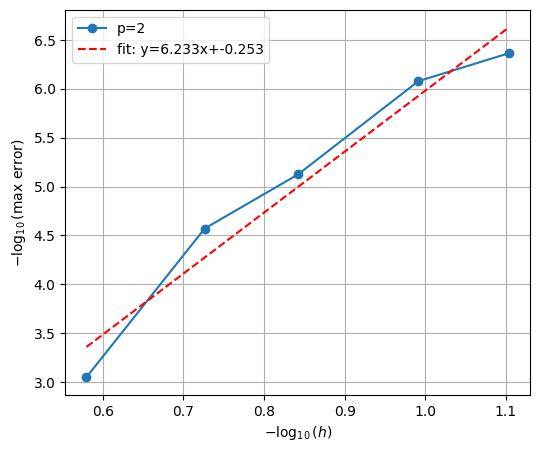

In [5]:
key = 100
np.random.seed(key)

NN = [20,40,70,120,200]
# KK = [25,40,60,120,135]
KK = [25,40,50,125,135]
RR = [1e-12,1e-12,1e-12,1e-14,1e-14]

for qi, n_local in enumerate(NN):
    print(f'Run Q={qi+1}, N_local_per_patch={n_local}')
    N_patch_grid = 5
    N_local_per_patch = n_local
    N_boundary = n_local
    R_ptch = 0.8
    mode = "c-rbf-pum"
    # generate points
    X_inner, X_boundary, _, _ ,_ = generator_points_star(
    N_patch_grid, N_local_per_patch, N_boundary, R_ptch, mode)

    # assemble X,Y
    X = np.vstack([X_inner, X_boundary])
    print(f"X.shape",X.shape[0])
    Yin = X_inner
    Yb = X_boundary
    Y = np.vstack([Yin, Yb])
    order = 2 
    h = fill_distance(X)
    H[order,qi] = h
    reg = RR[qi]
    K = KK[qi]
    
    u_true = u_func(Y[:,0:1], Y[:,1:2])
    UY,_,_= rfm_fd_poly_solve_poisson_nn(X, Yin, Yb, f_func, g_func, Phi, K, reg, order)
    error = np.max(np.abs(UY - u_true))
    e = np.linalg.norm(UY - u_true)/np.linalg.norm(u_true)
    E[order,qi] = e
    print(f'h = {h:.3e}, max abs error = {e:.3e}')


x = -np.log10(H[order,:])
y = -np.log10(E[order,:])
mask = np.isfinite(x) & np.isfinite(y)
if np.count_nonzero(mask) >= 2:
    slope, intercept = np.polyfit(x[mask], y[mask], 1)
    print(f'slope = {slope:.6f}, bias = {intercept:.6f}')
    # 绘图并画出拟合直线
    xx = np.linspace(x[mask].min(), x[mask].max(), 100)
    yy = slope * xx + intercept
    plt.figure(figsize=(6,5))
    plt.plot(x, y, marker='o', linestyle='-', label=f'p={order}')
    plt.plot(xx, yy, 'r--', label=f'fit: y={slope:.3f}x+{intercept:.3f}')
    # plt.plot(xx, yy, 'r--', label='')
    plt.xlabel(r'$- \log_{10}(h)$')
    plt.ylabel(r'$- \log_{10}(\mathrm{max\ error})$')
    plt.legend()
    plt.grid(True)
    # plt.title('p = 2, Convergence scatter and linear fitting')
    # plt.savefig(f'./result/p={order}_convergence_scatter_xcos.eps', bbox_inches='tight')
    plt.show()


Run Q=1, N_local_per_patch=20
X.shape 183
h = 2.631e-01, max abs error = 5.428e-04
Run Q=2, N_local_per_patch=40
X.shape 366
h = 1.877e-01, max abs error = 1.966e-05
Run Q=3, N_local_per_patch=70
X.shape 644
h = 1.438e-01, max abs error = 5.710e-06
Run Q=4, N_local_per_patch=120
X.shape 1100
h = 1.020e-01, max abs error = 2.267e-07
Run Q=5, N_local_per_patch=200
X.shape 1823


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


h = 7.872e-02, max abs error = 6.208e-08
slope = 7.515738, bias = -0.965509


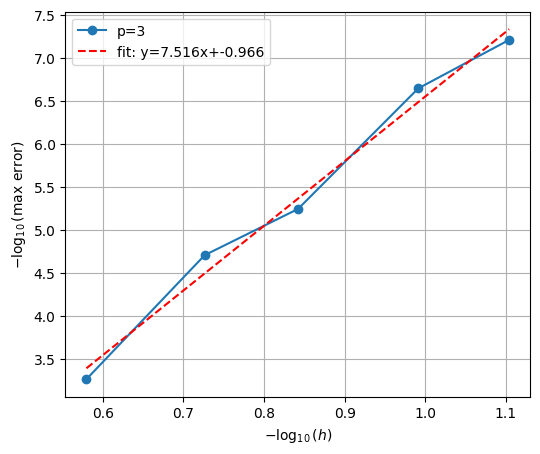

In [6]:
key = 100
np.random.seed(key)

NN = [20,40,70,120,200]
KK = [30,50,50,120,150]
RR = [1e-12,1e-12,1e-12,1e-13,1e-14]
for qi, n_local in enumerate(NN):
    print(f'Run Q={qi+1}, N_local_per_patch={n_local}')
    N_patch_grid = 5
    N_local_per_patch = n_local
    N_boundary = n_local
    R_ptch = 0.8
    mode = "c-rbf-pum"
    # generate points
    X_inner, X_boundary, _, _ ,_ = generator_points_star(
    N_patch_grid, N_local_per_patch, N_boundary, R_ptch, mode)
    order = 3
    # assemble X,Y
    X = np.vstack([X_inner, X_boundary])
    print(f"X.shape",X.shape[0])
    Yin = X_inner
    Yb = X_boundary
    Y = np.vstack([Yin, Yb])

    h = fill_distance(X)
    H[order,qi] = h
    reg = RR[qi]
    K = KK[qi]
    
    u_true = u_func(Y[:,0:1], Y[:,1:2])
    UY,_,_= rfm_fd_poly_solve_poisson_nn(X, Yin, Yb, f_func, g_func, Phi, K, reg, order)
    error = np.max(np.abs(UY - u_true))
    e = np.linalg.norm(UY - u_true)/np.linalg.norm(u_true)
    E[order,qi] = e
    print(f'h = {h:.3e}, max abs error = {e:.3e}')


x = -np.log10(H[order,:])
y = -np.log10(E[order,:])
mask = np.isfinite(x) & np.isfinite(y)
if np.count_nonzero(mask) >= 2:
    slope, intercept = np.polyfit(x[mask], y[mask], 1)
    print(f'slope = {slope:.6f}, bias = {intercept:.6f}')
    # 绘图并画出拟合直线
    xx = np.linspace(x[mask].min(), x[mask].max(), 100)
    yy = slope * xx + intercept
    plt.figure(figsize=(6,5))
    plt.plot(x, y, marker='o', linestyle='-', label='p=3')
    plt.plot(xx, yy, 'r--', label=f'fit: y={slope:.3f}x+{intercept:.3f}')
    # plt.plot(xx, yy, 'r--', label='')
    plt.xlabel(r'$- \log_{10}(h)$')
    plt.ylabel(r'$- \log_{10}(\mathrm{max\ error})$')
    plt.legend()
    plt.grid(True)
    # plt.title('p = 3, Convergence scatter and linear fitting')
    plt.savefig(f'./result/p={order}_convergence_scatter_xcos.eps', bbox_inches='tight')
    plt.show()


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


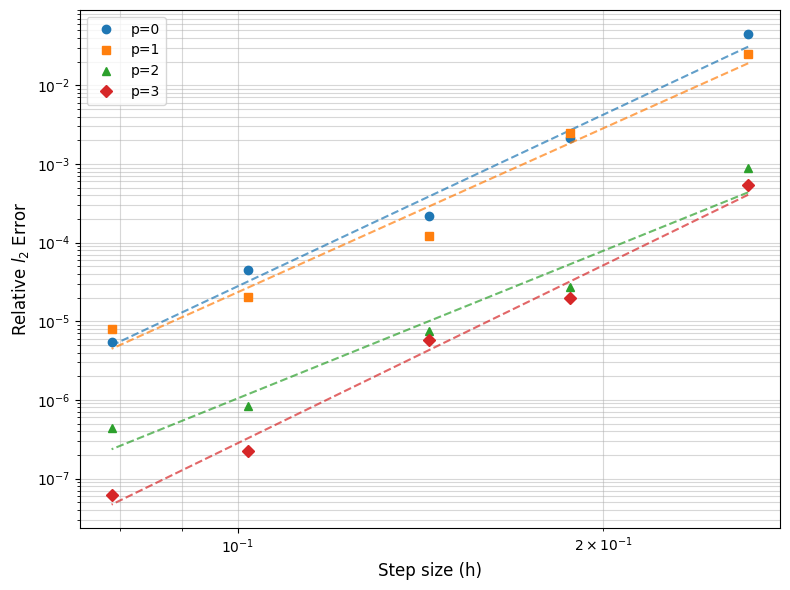

In [7]:
markers = ['o', 's', '^', 'D', 'v']  
colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'tab:gray']
labels = ['p=0', 'p=1', 'p=2', 'p=3',"FEM"]

plt.figure(figsize=(8, 6))
for i in range(4):
    h = H[i, :]
    e = E[i, :]
    log_h = np.log(h)
    log_e = np.log(e)
    slope, intercept = np.polyfit(log_h, log_e, 1)
    fit_e = np.exp(intercept) * h**slope
    plt.loglog(h, e, markers[i], color=colors[i], label=f'{labels[i]}')
    plt.loglog(h, fit_e, linestyle='--', color=colors[i], alpha=0.7)


# h = np.array([0.226473316206159,0.117514159784914,0.0640581633226791,])
# e = np.array([0.000565997277071441,0.000143535417042626,3.62243806175985e-05,])
# log_h = np.log(h)
# log_e = np.log(e)
# slope, intercept = np.polyfit(log_h, log_e, 1)
# fit_e = np.exp(intercept) * h**slope
# plt.loglog(h, e, markers[4], color=colors[4], label=f'{labels[4]}')
# plt.loglog(h, fit_e, linestyle='--', color=colors[4], alpha=0.7)



plt.xlabel('Step size (h)', fontsize=12)
plt.ylabel('Relative $l_2$ Error', fontsize=12)
# plt.title('Convergence Study: Least Squares Fit', fontsize=14)
plt.grid(True, which="both", ls="-", alpha=0.5)
plt.legend()
plt.tight_layout()
plt.savefig('./result/poisson2d_rfmfd_p=0123_convergence_scatter_xcos.eps', bbox_inches='tight')
plt.show()

$Operator learning$

In [1]:
import time
import torch
import scipy
from scipy.io import loadmat
import numpy as np
import matplotlib.pyplot as plt
import torch.nn as nn
from scipy.spatial import cKDTree, distance
from scipy.linalg import cholesky
from scipy.sparse import lil_matrix
from scipy.sparse.linalg import spsolve
import matplotlib.pyplot as plt

dtype = torch.float64
device = torch.device('cuda:1' if torch.cuda.is_available() else 'cpu')

def relative_loss(predict, exact):
    error = torch.sqrt(torch.sum((predict - exact) ** 2)) / torch.sqrt(torch.sum((exact) ** 2))
    return error

def vandercorput(n, base):
    """
    Vectorized van der Corput for n = array-like nonnegative integers and given base.
    Returns array of same shape as n with values in [0,1).
    """
    n = np.asarray(n, dtype=np.int64)
    # compute digits for each n by repeated division
    out = np.zeros_like(n, dtype=np.float64)
    denom = base
    current = n.copy()
    while np.any(current > 0):
        digit = current % base
        out += digit / denom
        current = current // base
        denom *= base
    return out

def halton_sequence(N, dim):
    """
    Generate first N points of Halton sequence in `dim` dimensions.
    Uses first `dim` primes as bases.
    Returns array shape (N, dim) with values in [0,1).
    """
    # small prime list sufficient for moderate dim
    primes_list = [2, 3, 5, 7, 11, 13, 17, 19, 23, 29, 31, 37, 41, 43, 47, 53, 59]
    if dim > len(primes_list):
        raise ValueError("Requested dimension too large for built-in primes list.")
    bases = primes_list[:dim]
    n_idx = np.arange(0, N, dtype=np.int64)  # n = 0..N-1
    H = np.empty((N, dim), dtype=np.float64)
    for j, b in enumerate(bases):
        H[:, j] = vandercorput(n_idx, b)
    return H

def generator_points_star(N_patch_grid,
                     N_local_per_patch,
                     N_boundary,
                     R_ptch,
                     mode="c-rbf-pum"):
    """
    Generate points on a star-shaped region and patch covering.

    Parameters
    ----------
    N_patch_grid : int
        number of patches per dimension (grid)
    N_local_per_patch : int
        target local points per patch (used as halton sample size per patch)
    N_boundary : int
        number of boundary points
    R_ptch : float
        patch radius
    mode : str
        "c-rbf-pum" or "ls-rbf-pum"

    Returns
    -------
    X_inner : ndarray (N_x,2)
        concatenated interior/source points
    X_boundary : ndarray (N_boundary,2)
        boundary points (uniform in theta)
    ptch : dict
        {'C': array(P,2), 'R': array(P,) } patch centers and radii
    grid_eval : ndarray (N_eval,2)
        evaluation/prediction points (depends on mode)
    """
    # -------------------------
    # 1. star region radial function
    def r_max_func(theta):
        return 2.0 * (0.7 + 0.12 * (np.sin(6*theta) + np.sin(3*theta)))

    # vector theta for plotting / sampling
    theta_plot = np.linspace(0.0, 2*np.pi, 1000, endpoint=False)
    r_plot = r_max_func(theta_plot)
    x_plot = r_plot * np.cos(theta_plot)
    y_plot = r_plot * np.sin(theta_plot)

    x_min, x_max = x_plot.min(), x_plot.max()
    y_min, y_max = y_plot.min(), y_plot.max()
    R_container = r_plot.max()

    # helper: is point(s) inside star region (vectorized)
    def is_inside_star(x, y):
        x = np.asarray(x)
        y = np.asarray(y)
        r = np.sqrt(x**2 + y**2)
        theta = np.arctan2(y, x)
        theta = np.where(theta < 0, theta + 2*np.pi, theta)
        r_limit = r_max_func(theta)
        TOL = 1e-12
        return r <= (r_limit + TOL)

    # -------------------------
    # 2. Patch grid parameters
    Domain_size = max(x_max - x_min, y_max - y_min)
    num_patches_1D = int(N_patch_grid)
    # avoid division by zero when Domain_size small
    if num_patches_1D <= 1:
        del_param = 0.0
    else:
        del_param = (num_patches_1D - Domain_size / R_ptch) / (num_patches_1D - 1)
    patch_spacing = 2 * R_ptch * (1 - del_param)

    # create center grid in bounding square [Grid_min, Grid_max]^2
    Grid_min = min(x_min, y_min)
    Grid_max = max(x_max, y_max)
    Cx = np.linspace(Grid_min, Grid_max, num_patches_1D)
    Cy = np.linspace(Grid_min, Grid_max, num_patches_1D)
    Cxv, Cyv = np.meshgrid(Cx, Cy)
    C_all = np.column_stack([Cxv.ravel(), Cyv.ravel()])
    R_all = R_ptch * np.ones((C_all.shape[0],), dtype=np.float64)

    # For each candidate patch, sample its circle boundary points and check overlap
    theta_circ = theta_plot  # reuse dense sample
    # build for all centers: shifted circle coordinates
    # shape (num_centers, n_theta)
    bc_x = C_all[:, 0:1] + R_all[:, None] * np.cos(theta_circ)[None, :]
    bc_y = C_all[:, 1:] + R_all[:, None] * np.sin(theta_circ)[None, :]

    # Determine which patch has any boundary point inside the star region
    # is_inside_star accepts arrays; compute over all boundary samples
    inside_flags = is_inside_star(bc_x, bc_y)  # shape (num_centers, n_theta)
    id_keep = np.where(inside_flags.sum(axis=1) > 0)[0]

    C_kept = C_all[id_keep, :]
    R_kept = R_all[id_keep]
    ptch = {'C': C_kept, 'R': R_kept}
    P = C_kept.shape[0]

    # -------------------------
    # 3. Generate RBF center points per patch (Halton sampling in polar coords)
    X_inner_points = []
    grid_eval_points = []  # for c-rbf-pum mode
    # we will use exactly N_local_per_patch halton samples per patch (as in your adjusted code)
    N_generate = int(N_local_per_patch)
    # for LS mode, generate global evaluation grid if requested
    if mode == "ls-rbf-pum":
        # create a dense grid that covers the bounding box and then trim to star region
        n_grid = int(round(np.sqrt(P * N_generate) * 1.5))
        if n_grid < 2:
            n_grid = 2
        x_eval = np.linspace(x_min, x_max, n_grid)
        y_eval = np.linspace(y_min, y_max, n_grid)
        Xg, Yg = np.meshgrid(x_eval, y_eval)
        grid_pts = np.column_stack([Xg.ravel(), Yg.ravel()])
        mask_grid = is_inside_star(grid_pts[:, 0], grid_pts[:, 1])
        grid_eval_all = grid_pts[mask_grid, :]
    else:
        grid_eval_all = np.empty((0, 2))

    # Halton base samples for polar mapping (u,v)
    H = halton_sequence(N_generate, 2)  # (N_generate, 2)
    u = H[:, 0]
    v = H[:, 1]

    for i in range(P):
        C = C_kept[i, :]
        R = R_kept[i]
        theta_local = 2.0 * np.pi * u  # (N_generate,)
        r_local = np.sqrt(v) * R
        x_local = r_local * np.cos(theta_local) + C[0]
        y_local = r_local * np.sin(theta_local) + C[1]
        if mode == "c-rbf-pum":
            inside_mask = is_inside_star(x_local, y_local)
            X_candidate = np.column_stack([x_local[inside_mask], y_local[inside_mask]])
            # keep all that are inside; you may trim to desired count elsewhere
            X_inner_points.append(X_candidate)
            grid_eval_points.append(X_candidate)
        elif mode == "ls-rbf-pum":
            # do not clip to patch by star region (as MATLAB's ls mode keeps all)
            X_candidate = np.column_stack([x_local, y_local])
            X_inner_points.append(X_candidate)
            # N_total in MATLAB set to P * N_generate; we follow that
        else:
            raise ValueError("Unrecognized mode: {}".format(mode))

    if len(X_inner_points) > 0:
        X_inner = np.vstack([arr for arr in X_inner_points if arr.shape[0] > 0])
    else:
        X_inner = np.empty((0, 2))

    if mode == "c-rbf-pum":
        # grid_eval collects retained candidates
        if len(grid_eval_points) > 0:
            grid_eval = np.vstack([arr for arr in grid_eval_points if arr.shape[0] > 0])
        else:
            grid_eval = np.empty((0, 2))
    else:
        grid_eval = grid_eval_all

    # -------------------------
    # 4. Generate boundary points (uniform in theta)
    theta_bnd = np.linspace(0.0, 2*np.pi, N_boundary, endpoint=False)
    r_bnd = r_max_func(theta_bnd)
    x_bnd = r_bnd * np.cos(theta_bnd)
    y_bnd = r_bnd * np.sin(theta_bnd)
    X_boundary = np.column_stack([x_bnd, y_bnd])

    # also return boundary curve for plotting convenience
    boundary_curve = np.column_stack([x_plot, y_plot])

    return X_inner, X_boundary, ptch, grid_eval, boundary_curve

# --------------------------
# Plotting wrapper
# --------------------------
def plot_generator_points(X_inner, X_boundary, ptch, grid_eval, boundary_curve, figsize1=(7,6), figsize2=(7,6)):
    """
    Draw two figures similar to MATLAB version:
    - Figure 1: patch coverage, interior points, boundary points, region boundary
    - Figure 2: prediction grid and boundary
    """
    C = ptch['C']
    R = ptch['R']
    P = C.shape[0]
    theta_circ = np.linspace(0, 2*np.pi, 200)

    # Figure 1
    plt.figure(figsize=figsize1)
    ax = plt.gca()
    # patch circles (dashed)
    for i in range(P):
        x_circ = C[i,0] + R[i] * np.cos(theta_circ)
        y_circ = C[i,1] + R[i] * np.sin(theta_circ)
        ax.plot(x_circ, y_circ, linestyle=':', color='k', linewidth=1.2)
        ax.plot(C[i,0], C[i,1], marker='x', color='g', markersize=6)
    # region boundary
    ax.plot(boundary_curve[:,0], boundary_curve[:,1], 'r-', linewidth=0.5)
    # interior points
    if X_inner.shape[0] > 0:
        ax.scatter(X_inner[:,0], X_inner[:,1], s=10, c='b', marker='.', label='Interior points')
    # boundary points
    if X_boundary.shape[0] > 0:
        ax.scatter(X_boundary[:,0], X_boundary[:,1], s=18, c='k', marker='.', label='Boundary points')
    ax.set_aspect('equal', 'box')
    ax.set_title('Patch Coverage and Node Distribution in the Star-Shaped Domain', fontsize=12)
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.legend()
    ax.grid(True)
    plt.tight_layout()

    # Figure 2: prediction grid
    plt.figure(figsize=figsize2)
    ax2 = plt.gca()
    ax2.plot(boundary_curve[:,0], boundary_curve[:,1], 'r-', linewidth=0.5)
    if grid_eval is not None and grid_eval.shape[0] > 0:
        ax2.scatter(grid_eval[:,0], grid_eval[:,1], s=8, c='r', marker='.', label='Evaluation Points')
    if X_boundary.shape[0] > 0:
        ax2.scatter(X_boundary[:,0], X_boundary[:,1], s=18, c='k', marker='.', label='Boundary Points')
    ax2.set_aspect('equal', 'box')
    ax2.set_title('Evaluation Point Distribution in the Star-Shaped Domain', fontsize=12)
    ax2.set_xlabel('x')
    ax2.set_ylabel('y')
    ax2.legend()
    ax2.grid(True)
    plt.tight_layout()
    plt.show()

class PhiNet(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(PhiNet, self).__init__()
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.output_size = output_size
        self.input_layer = nn.Linear(input_size, hidden_size, bias = None)
        self.hidden_layer = nn.Linear(hidden_size, hidden_size, bias = None)
        self.output_layer = nn.Linear(hidden_size, output_size, bias = None) 
	
    def forward(self, x): # r : (K,1)  or (K,K)
        K = x.shape[0]
        if x.shape[-1] != self.input_size:
            x = x.view(-1, self.input_size)
        output = self.input_layer(x)
        output = torch.sin(output)
        output = torch.cos(self.hidden_layer(output))
        output = self.output_layer(output)
        if output.shape[0] != K:
            output = output.view(K, -1)
        return output
	
    def initi(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight.data)
                if m.bias is not None:
                    # nn.init.normal_(m.bias, mean=0.0, std=1)
                    m.bias.data.zero_()



def laplacian_phi_wrt_y(phi_net, y, X, eps=1e-8):
    """
    y: tensor (1,2) evalution points, requires_grad = True
    X: tensor (K,2) source points
    Returns: phi_vals (K,1), laplacian_y (K,1), grad_y (K,2)
    """
    y = torch.tensor(y, dtype=torch.float64, device=device)
    X = torch.tensor(X, dtype=torch.float64, device=device)
    if y.dim()==1:
        y = y.unsqueeze(0)   # (1,2)
    K = X.shape[0]
    # compute r_j
    diff = y - X          # (K,2) if y (1,2)
    r = torch.norm(diff, dim=1, keepdim=True)   # (K,1)
    r = r.clamp(min=eps)  # 防止除零

    r.requires_grad_(True)    # 需要对 r 求导
    phi_vals = phi_net(r)     # (K,1)
    # phi_vals = phi_gauss(eps,r) # to check whether the laplace using autograd is correct

    # phi'(r)
    dphi_dr = torch.autograd.grad(
        outputs=phi_vals,
        inputs=r,
        grad_outputs=torch.ones_like(phi_vals),
        create_graph=True,
        retain_graph=True,
    )[0]   # (K,1)

    # phi''(r)
    d2phi_dr2 = torch.autograd.grad(
        outputs=dphi_dr,
        inputs=r,
        grad_outputs=torch.ones_like(dphi_dr),
        create_graph=False,
        retain_graph=True
    )[0]   # (K,1)

    n = y.shape[1]  # dimension, n = 2 here
    lap_r = d2phi_dr2 + (n-1)/r * dphi_dr   # (K,1),
    # print("relative error between  is",relative_loss(lap_r, laplace_phi_gauss(eps, r)))
    # 一阶向量梯度 wrt y： ∇_y φ = φ'(r) * (y - x)/r
    grad_y = dphi_dr * (diff / r)    # broadcasting (K,2): (grad_y1,grad_y2) 
    phi_vals = phi_vals.detach().cpu().numpy()
    lap_r = lap_r.detach().cpu().numpy()
    grad_y = grad_y.detach().cpu().numpy()
    return phi_vals, lap_r, grad_y

def poly2D(Z, order):
    K = Z.shape[0]
    Norder = (order+1)*(order+2)//2
    P = np.zeros((K, Norder))
    idx = 0
    for i in range(order+1):
        for j in range(order+1-i):
            P[:, idx] = (Z[:,0]**i) * (Z[:,1]**j)
            idx += 1
    return P

def poly2D_at_point(y, order):
    """Generate column vector of poly basis at single point y (2D)"""
    Norder = (order+1)*(order+2)//2
    p_y = np.zeros((Norder,1))
    idx = 0
    for i in range(order+1):
        for j in range(order+1-i):
            p_y[idx,0] = (y[0]**i) * (y[1]**j)
            idx += 1
    return p_y

def laplacian_poly2D(order, y):
    """
    y: (2,) point
    return: column vector (Norder,1) of Laplacian evaluated at y
    """
    Norder = (order+1)*(order+2)//2
    lap = np.zeros((Norder,1))
    idx = 0
    for i in range(order+1):
        for j in range(order+1-i):
            val = 0.0
            if i >= 2:
                val += i*(i-1)*y[0]**(i-2) * y[1]**j
            if j >= 2:
                val += j*(j-1)*y[0]**i * y[1]**(j-2)
            lap[idx,0] = val
            idx += 1
    return lap

def rfm_fd_poly_solve_poisson_nn(X, Yin, Yb, f_func, g_func, Phi, K, reg, order):
    """
    X:  (N,2)  RBF source points
    Yin: (M1,2) interior points
    Yb:  (M2,2) boundary points
    f_func, g_func: Python callable returning torch tensor
    K: number of neighbors
    order: polynomial order (1,2,3,...)
    """
    Norder = (order + 1) * (order + 2) // 2  # number of polynomial basis in 2D
    # Combine evaluation points
    Y = np.concatenate([Yin, Yb], axis=0)
    # Compute distance to all source points
    M = Y.shape[0]
    N = X.shape[0]
    M2 = Yb.shape[0] # number of boundary points
    M1 = M - M2

    tree = cKDTree(X)
    dist, idx = tree.query(Y, k=K, workers=-1)  # (M,K)

    # Construct sparse L matrix
    L = lil_matrix((M, N),dtype=np.float64)
    LL = lil_matrix((M, N),dtype=np.float64)
    # W_ide = np.zeros((M, K+Norder))
    # W_lap = np.zeros((M, K+Norder))
    # Construct RHS
    RHS = np.zeros((M,1))
    if callable(f_func):
        RHS[:M1,0:1] = f_func(Yin[:,0:1], Yin[:,1:2])
    elif isinstance(f_func, np.ndarray):
        RHS[:M1,:] = f_func[:,None] # (M1,1)
    else:
        raise ValueError("f_func must be callable or numpy array")
    if callable(g_func):
        RHS[-M2:,0:1] = g_func(Yb[:,0:1], Yb[:,1:2])
    elif isinstance(g_func, np.ndarray):
        RHS[-M2:,:] = g_func[:,None] # (M2,1)
    else:
        raise ValueError("g_func must be callable or numpy array")

    O = np.zeros((Norder,Norder))
    start_time = time.time()
    for i in range(M):
        RHS_lap = np.zeros((K+Norder,1))
        RHS_ide = np.ones((K+Norder,1))
        AP = np.zeros((K+Norder,K+Norder))
        P = np.ones((K,Norder))
        y = Y[i,:] # (2,)
        idx_local = idx[i,:]    # (K,)
        Z = X[idx_local]       # (K,2)
        dist_ZZ = distance.cdist(Z, Z, metric='euclidean') # (K,K)
        dist_ZZ = torch.as_tensor(dist_ZZ, dtype = torch.float64, device = device)
        Phi_jj = Phi(dist_ZZ) # (K,K)
        Phi_jj = Phi_jj.detach().cpu().numpy()
        phi_xj, lap_phi, _  = laplacian_phi_wrt_y(Phi, y, Z, eps=1e-8) # (K,1)
        ## W_ide
        P = poly2D(Z, order)  # (K,Norder)
        AP[:K,:] = np.concatenate([Phi_jj,P], axis = 1) # (K,K+3)
        AP[K:,:-Norder] = P.T # (6,K)
        ## W_ide, RHS_ide

        p_y = poly2D_at_point(y, order)  # (Norder,1)
        RHS_ide[:K,0] = phi_xj[:,0]                           # shape (K,)
        RHS_ide[K:,0] = p_y[:,0]
        AP = AP + reg * np.eye(K+Norder)
        w_ide = np.linalg.solve(AP,RHS_ide).T # (1,K+3)
        # W_ide[i:i+1,:] = w_ide
        ## W_lap
        # Laplace weights: laplace_phi = Phi_jj w_lap
        
        RHS_lap[:K,0] = lap_phi[:,0]
        RHS_lap[K:,0] = laplacian_poly2D(order, y)[:,0]
        w_lap = np.linalg.solve(AP,RHS_lap).T # (1,K+Noder)
        # W_lap[i:i+1,:] = w_lap

        L[i, idx_local] = L[i, idx_local] - w_lap[:,:K] if i < M1 else  L[i, idx_local] + w_ide[:,:K]
        LL[i,idx_local] = LL[i,idx_local] + w_ide[:,:K]
    # ===========================================================
    # Solve linear system L U = RHS
    # ===========================================================
    end_time = time.time()
    print("Compiling matrix cost",end_time - start_time,"seconds")
    
    L1 = L.tocsr()
    if M == N:
        UX = spsolve(L1, RHS)
    else:
        Q, R = np.linalg.qr(L1.toarray(), mode='reduced')
        UX = np.linalg.solve(R, Q.T @ RHS)

    # ===========================================================
    # Evaluate solution at Y
    # ===========================================================
    LL = LL.tocsr()
    UY = LL.dot(UX).reshape(-1,1)
    UY[M1:,:] = g_func[:,None]
    return UY,L,LL

# # ===========================================================
# # Evaluate solution at Y
# # ===========================================================
def test_solver(L, LL, RHS):
    """
    L  : (M,N) sparse operator matrix
    LL : (M,N) sparse interpolation matrix
    RHS: (M,Q) numpy array

    Returns
    -------
    UY : (M,Q) numpy array
    """
    L = L.tocsr()
    LL = LL.tocsr()

    M, N = L.shape
    Q = RHS.shape[1]
    # -------------------------
    # Solve L UX = RHS
    # -------------------------
    if M == N:
        # spsolve supports multiple RHS
        UX = spsolve(L, RHS)          # (N,Q)
    else:
        Q, R = np.linalg.qr(L.toarray(), mode='reduced')
        UX = np.linalg.solve(R, Q.T @ RHS)
    # -------------------------
    # Evaluate at Y
    # -------------------------
    UY = LL @ UX                      # (M,Q)
    return UY

def rfm_fd_solve_poisson_nn(X, Yin, Yb, f_func, g_func, Phi, K, reg):
    """
    X:  (N,2)  RBF source points
    Yin: (M1,2) interior points
    Yb:  (M2,2) boundary points
    f_func, g_func: Python callable returning torch tensor
    K: number of neighbors
    order: 0
    """
    # Combine evaluation points
    Y = np.concatenate([Yin, Yb], axis=0)
    # Compute distance to all source points
    M = Y.shape[0]
    N = X.shape[0]
    M2 = Yb.shape[0] # number of boundary points
    M1 = M - M2

    tree = cKDTree(X)
    dist, idx = tree.query(Y, k=K, workers=-1)  # (M,K)

    # Construct sparse L matrix
    L = lil_matrix((M, N),dtype=np.float64)
    LL = lil_matrix((M, N),dtype=np.float64)
    # W_ide = np.zeros((M, K))
    # W_lap = np.zeros((M, K))
    # Construct RHS
    RHS = np.zeros((M,1))
    if callable(f_func):
        RHS[:M1,0:1] = f_func(Yin[:,0:1], Yin[:,1:2])
    elif isinstance(f_func, np.ndarray):
        RHS[:M1,:] = f_func[:,None] # (M1,1)
    else:
        raise ValueError("f_func must be callable or numpy array")
    if callable(g_func):
        RHS[-M2:,0:1] = g_func(Yb[:,0:1], Yb[:,1:2])
    elif isinstance(g_func, np.ndarray):
        RHS[-M2:,:] = g_func[:,None] # (M2,1)
    else:
        raise ValueError("g_func must be callable or numpy array")
    start_time = time.time()
    for i in range(M):
        RHS_lap = np.zeros((K,1))
        RHS_ide = np.ones((K,1))
        A = np.zeros((K,K))
        y = Y[i,:] # (2,)
        idx_local = idx[i,:]    # (K,)
        Z = X[idx_local]       # (K,2)
        dist_ZZ = distance.cdist(Z, Z, metric='euclidean') # (K,K)
        dist_ZZ = torch.as_tensor(dist_ZZ, dtype = torch.float64, device = device)
        Phi_jj = Phi(dist_ZZ) # (K,K)
        Phi_jj = Phi_jj.detach().cpu().numpy()
        phi_xj, lap_phi, _  = laplacian_phi_wrt_y(Phi, y, Z, eps=1e-8) # (K,1)
        ## RHS_lap, RHS_ide
        RHS_lap = lap_phi
        RHS_ide = phi_xj
        ## W_ide, W_lap
        A  =  Phi_jj  + reg * np.eye(K) # (K,K)
        w_ide = np.linalg.solve(A,RHS_ide).T # (1,K+3)
        # W_ide[i:i+1,:] = w_ide
        w_lap = np.linalg.solve(A,RHS_lap).T # (1,K+Noder)
        # W_lap[i:i+1,:] = w_lap
        L[i, idx_local] = L[i, idx_local] - w_lap if i < M1 else L[i, idx_local] + w_ide
        LL[i,idx_local] = LL[i,idx_local] + w_ide[:,:K]
    # ===========================================================
    # Solve linear system L U = RHS
    # ===========================================================
    end_time = time.time()
    print("Compiling matrix cost",end_time - start_time,"seconds")
    
    L1 = L.tocsr()
    if M == N:
        UX = spsolve(L1, RHS)
    else:
        Q, R = np.linalg.qr(L1.toarray(), mode='reduced')
        UX = np.linalg.solve(R, Q.T @ RHS)

    # ===========================================================
    # Evaluate solution at Y
    # ===========================================================
    LL = LL.tocsr()
    UY = LL.dot(UX).reshape(-1,1)
    UY[M1:,:] = g_func[:,None]
    return UY,L,LL


def fill_distance(nodes):
    """
    nodes: (N, d) numpy array
    returns: scalar h = max_i min_{j != i} ||x_i - x_j||
    """
    nodes = np.asarray(nodes)
    if nodes.shape[0] <= 1:
        return 0.0
    tree = cKDTree(nodes)
    # query 2 nearest (including itself at dist 0), then take second column
    dists, _ = tree.query(nodes, k=2, workers=-1)
    # dists[:,0] == 0, so use dists[:,1]
    min_neigh = dists[:, 1]
    return np.float64(np.max(min_neigh))

X_inner.shape: 2435, X_boundary.shape:300
Compiling matrix cost 15.899956941604614 seconds
p =  1 u_true.shape:  (15689, 1)
0.06259465619874627
L infity error in u: 6.259e-02
Relative L2 error in u: 1.479e-02


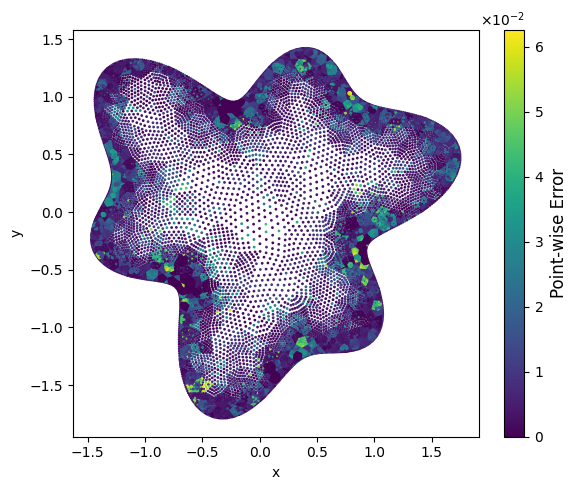

In [2]:

key = 100
np.random.seed(key)
torch.manual_seed(key)
torch.cuda.manual_seed_all(key)

hidden_size = 50
Phi = PhiNet(input_size=1, hidden_size=hidden_size, output_size=1).to(device) #
Phi.initi()
Phi = Phi.double() 

# u_func = lambda x, y: x * np.cos(y)
# f_func = lambda x, y: 0 * np.cos(y) + x * np.cos(y)
# g_func = lambda x, y: x * np.cos(y)
# #===========================================================
# #==================== Evaluate points Y ====================
# #===========================================================
# data = loadmat('./data_poisson/mydata_sigma1_l0_25.mat')
# data = loadmat('./data_poisson/mydata_100_pdetool_4029.mat')
data = loadmat('./data_poisson/mydata_100_pdetool_15689.mat')

p,f_0,u_0,f_new,u_new, index_in,index_bc = data['p'],data['f_0'],data['u_0'],data['F'],data['U'],data['in'],data['bc']  # sigma = 1, l = 0.25
index_in, index_bc = (index_in - 1).reshape(-1),(index_bc - 1).reshape(-1) # matlab to python index
# print(u_0.shape, f_0.shape, p.shape,f_new.shape) # (914, 1) (914, 1)
torchdtype = torch.float64
Y = p
M = Y.shape[0]
M2 = index_bc.shape[0]# 生成样本点已经给定
M1 = M - M2
# # print(index_in.shape, index_bc.shape)
testnum = 0
Yin,Yb = Y[index_in,:],Y[index_bc,:] # interior and boundary points
f_func = f_new[index_in,testnum] 
g_func = u_new[index_bc,testnum]
order = 1
K = 50
reg = 1e-14
u_true = u_new[:,testnum]
u_true = np.concatenate([u_true[index_in,None],u_true[index_bc,None]],axis=0)
# #===========================================================
# #==================== Source points X ====================
# #===========================================================

N_patch_grid = 5
N_local_per_patch = 300
N_boundary = 300
R_ptch = 0.8
mode = "c-rbf-pum"
# generate points
X_inner, X_boundary, _, _ , _ = generator_points_star(
N_patch_grid, N_local_per_patch, N_boundary, R_ptch, mode)
print(f"X_inner.shape: {X_inner.shape[0]}, X_boundary.shape:{X_boundary.shape[0]}")
X = np.vstack([X_inner, X_boundary])

# X = p

# # ===========================================================
if order == 0:
    UY,L,LL = rfm_fd_solve_poisson_nn(X, Yin, Yb, f_func, g_func, Phi, K, reg)
else:
    UY,L,LL = rfm_fd_poly_solve_poisson_nn(X, Yin, Yb, f_func, g_func, Phi, K, reg, order)

# UY,L,LL = rfm_fd_poly_solve_poisson_nn(X, Yin, Yb, f_func, g_func, Phi, K, reg, order)

print("p = ", order, "u_true.shape: ",u_true.shape)
error = np.abs(UY - u_true)#/np.abs(u_true + 1e-6)
print(error.max().item())
print(f'L infity error in u: {error.max().item():.3e}')
error_u = np.linalg.norm(UY - u_true, 2) / np.linalg.norm(u_true, 2)
print(f'Relative L2 error in u: {error_u.item():.3e}')

import matplotlib.ticker as ticker
plt.figure(figsize=(6,5))
sc = plt.scatter(Y[:,0], Y[:,1], c=np.abs(UY - u_true), cmap='viridis', s=1)
cbar = plt.colorbar(sc)
cbar.set_label('Point-wise Error', fontsize=12)
formatter = ticker.ScalarFormatter(useMathText=True)
formatter.set_scientific(True)
formatter.set_powerlimits((0, 0))
cbar.ax.yaxis.set_major_formatter(formatter)
# plt.title(f'Augmented RFM-FD Point-wise Error (p = {order})')
plt.xlabel('x')
plt.ylabel('y')
plt.tight_layout()
# plt.savefig(f'./result/p={order}_error_xcos_operator.eps', bbox_inches='tight')
plt.show()


## |Y| \noneq |X|, k = 50
## order = 0, reg = 1e-12
## order = 1, reg = 1e-12
## order = 2, reg = 1e-12
## order = 3, reg = 1e-12 ,   效果 1e-12 >  1e-14 > 1e-11

## |Y| = |X|, k = 50
## order = 0, reg = 1e-14
## order = 1, reg = 1e-14
## order = 2, reg = 1e-14
## order = 3, reg = 1e-12 ,   效果 1e-12 >  1e-14 > 1e-11

(15689, 100) (14841, 100) (848, 100)
p = 1, inference time: 3.8760 秒


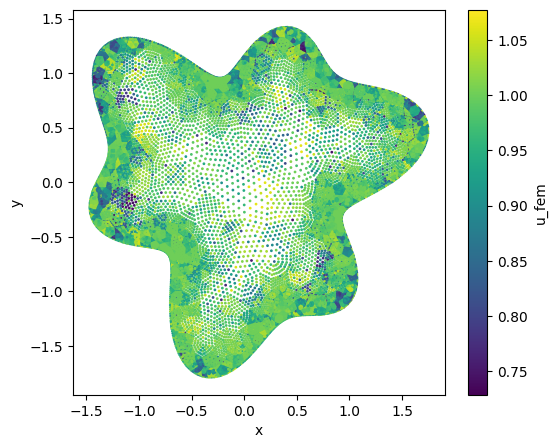

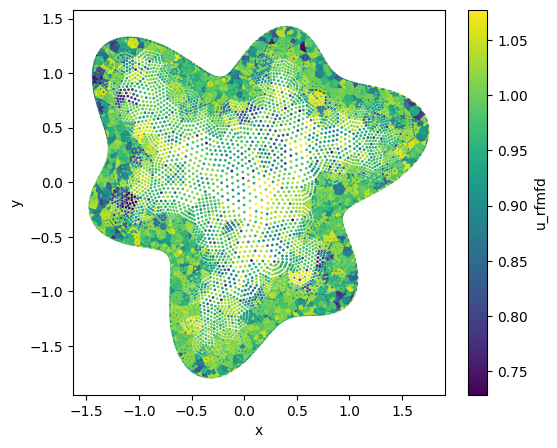

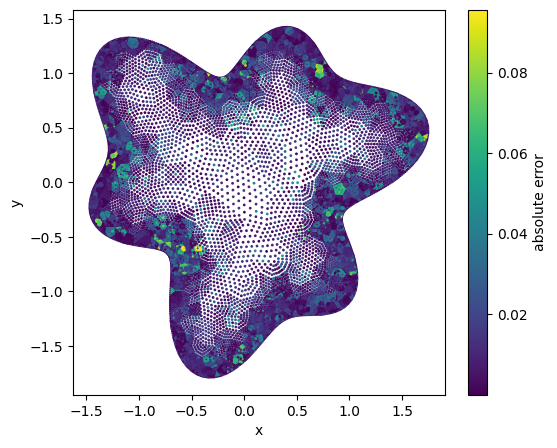

p = 1, test on 100 samples. The mean of max error: 7.928014e-02, and mean of relative L2 error: 1.967769e-02
p = 1, test on 100 samples. The variance of max error: 5.980005e-04, and variance of relative L2 error: 3.505127e-05


In [3]:
import time
E_inf, E_L2 = np.zeros((100,1)),np.zeros((100,1))
Yin,Yb = Y[index_in,:],Y[index_bc,:] # interior and boundary points
f_vec = f_new[index_in,:] 
g_vec = u_new[index_bc,:]

u_true = u_new
u_true = np.concatenate([u_true[index_in,:],u_true[index_bc,:]],axis=0)
print(u_true.shape, f_vec.shape, g_vec.shape)
RHS = np.concatenate([f_vec,g_vec],axis = 0 )

start_time = time.time()
UY = test_solver(L, LL, RHS)
end_time = time.time()
print(f"p = {order}, inference time: {end_time - start_time:.4f} 秒")

error_inf = np.abs(UY - u_true)
E_inf =  np.max(error_inf,axis = 0)
error_L2 = np.linalg.norm(UY - u_true, axis = 0) / np.linalg.norm(u_true, axis =0)
E_L2 = error_L2

avg_inf = np.mean(E_inf)
avg_L2 = np.mean(E_L2)
var_inf = np.var(E_inf)
var_L2 = np.var(E_L2)

np.random.seed(100)
q = np.random.randint(0,100)

import matplotlib.colors as mcolors

v_min = min(u_true[:, q].min(), UY[:, q].min())
v_max = max(u_true[:, q].max(), UY[:, q].max())
norm = mcolors.Normalize(vmin=v_min, vmax=v_max)
plt.figure(figsize=(6,5))
plt.scatter(Y[:,0], Y[:,1], c = u_true[:,q], cmap='viridis', s=1, norm=norm)
plt.colorbar(label='u_fem')
# plt.title(f'u_fem')
plt.xlabel('x')
plt.ylabel('y')
plt.savefig(f'./result/poisson2d_rfmfd_p={order}_u_fem_size{M}.eps', bbox_inches='tight')
plt.show()

plt.figure(figsize=(6,5))
plt.scatter(Y[:,0], Y[:,1], c = UY[:,q] , cmap='viridis', s=1, norm=norm)
plt.colorbar(label='u_rfmfd')
# plt.title(f'u_pred')
plt.xlabel('x')
plt.ylabel('y')
plt.savefig(f'./result/poisson2d_rfmfd_p={order}_u_rfmfd_size{M}.eps', bbox_inches='tight')
plt.show()

plt.figure(figsize=(6,5))
plt.scatter(Y[:,0], Y[:,1], c = error_inf[:,q], cmap='viridis', s=1)
plt.colorbar(label='absolute error')
# plt.title(f'Argumented RFM-FD\' point wise error with {order} order polynomial')
plt.xlabel('x')
plt.ylabel('y')
plt.savefig(f'./result/poisson2d_rfmfd_p={order}_error_size{M}.eps', bbox_inches='tight')
plt.show()

print(f"p = {order}, test on 100 samples. The mean of max error: {avg_inf:3e}, and mean of relative L2 error: {avg_L2:3e}")
print(f"p = {order}, test on 100 samples. The variance of max error: {var_inf:3e}, and variance of relative L2 error: {var_L2:3e}")

Compiling matrix cost 3.9890732765197754 seconds
(4029, 1)
0.10011574022344094
L infity error in u: 1.089e-01
Relative L2 error in u: 1.947e-02


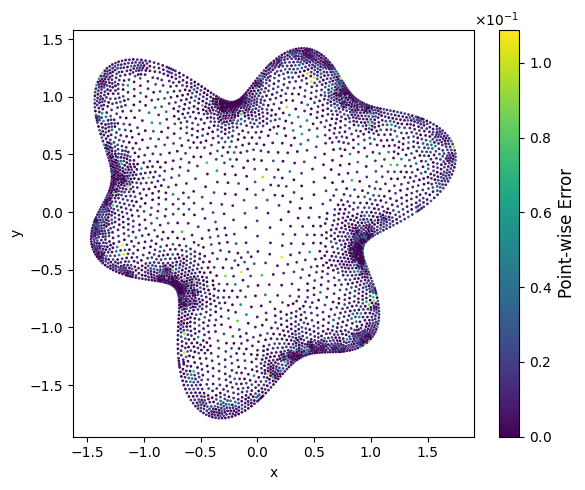

(4029, 100) (3605, 100) (424, 100)
p = 1, inference time: 0.4139 秒


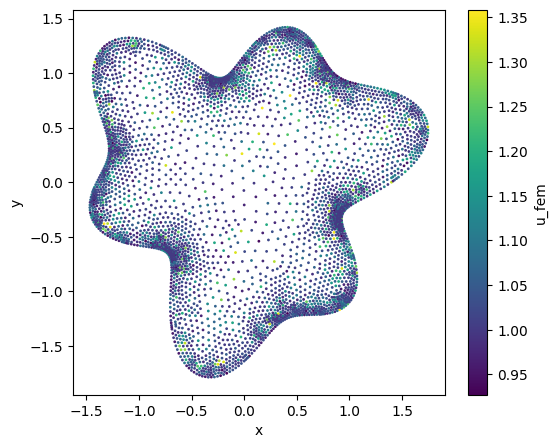

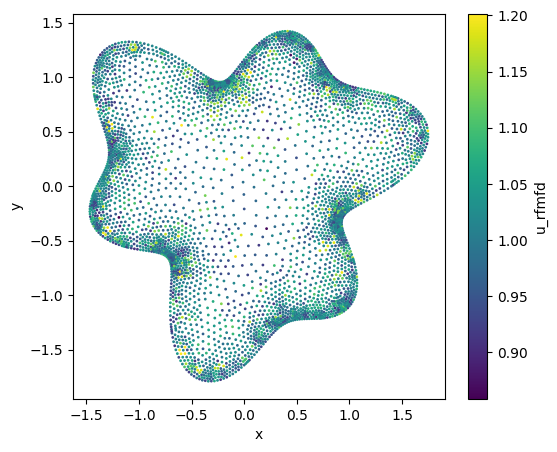

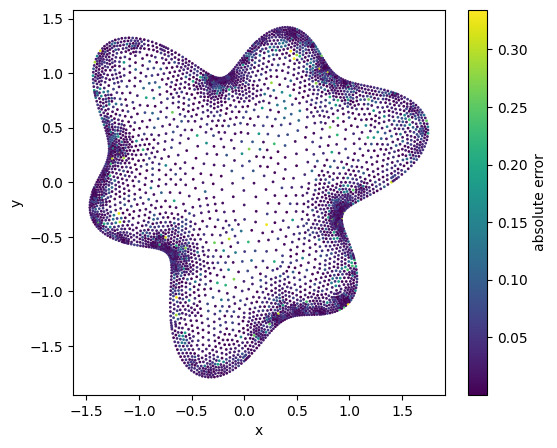

p = 1, test on 100 samples. The mean of max error: 1.884889e-01, and mean of relative L2 error: 3.357476e-02
p = 1, test on 100 samples. The variance of max error: 1.256128e-02, and variance of relative L2 error: 3.367155e-04


In [ ]:

key = 100
np.random.seed(key)
torch.manual_seed(key)
torch.cuda.manual_seed_all(key)

hidden_size = 50
Phi = PhiNet(input_size=1, hidden_size=hidden_size, output_size=1).to(device) #
Phi.initi()
Phi = Phi.double() 

# u_func = lambda x, y: x * np.cos(y)
# f_func = lambda x, y: 0 * np.cos(y) + x * np.cos(y)
# g_func = lambda x, y: x * np.cos(y)
# #===========================================================
# #==================== Evaluate points Y ====================
# #===========================================================
# data = loadmat('./data_poisson/mydata_sigma1_l0_25.mat')
data = loadmat('./data_poisson/mydata_100_pdetool_4029_1.mat')
# data = loadmat('./data_poisson/mydata_100_pdetool_15689.mat')

p,f_0,u_0,f_new,u_new, index_in,index_bc = data['p'],data['f_0'],data['u_0'],data['F'],data['U'],data['in'],data['bc']  # sigma = 1, l = 0.25
index_in, index_bc = (index_in - 1).reshape(-1),(index_bc - 1).reshape(-1) # matlab to python index
# print(u_0.shape, f_0.shape, p.shape,f_new.shape) # (914, 1) (914, 1)
torchdtype = torch.float64
Y = p
M = Y.shape[0]
M2 = index_bc.shape[0]# 生成样本点已经给定
M1 = M - M2
# # print(index_in.shape, index_bc.shape)
testnum = 0
Yin,Yb = Y[index_in,:],Y[index_bc,:] # interior and boundary points
f_func = f_new[index_in,testnum] 
g_func = u_new[index_bc,testnum]
order = 1
K = 50
reg = 1e-13
u_true = u_new[:,testnum]
u_true = np.concatenate([u_true[index_in,None],u_true[index_bc,None]],axis=0)
# #===========================================================
# #==================== Source points X ====================
# #===========================================================
# X = p
N_patch_grid = 5
N_local_per_patch = 200
N_boundary = 200
R_ptch = 0.8
mode = "c-rbf-pum"
# generate points
X_inner, X_boundary, _, _ , _ = generator_points_star(
N_patch_grid, N_local_per_patch, N_boundary, R_ptch, mode)
X = np.vstack([X_inner, X_boundary])

# # ===========================================================
# if order == 0:
#     UY,L,LL = rfm_fd_solve_poisson_nn(X, Yin, Yb, f_func, g_func, Phi, K, reg)
# else:
#     UY,L,LL = rfm_fd_poly_solve_poisson_nn(X, Yin, Yb, f_func, g_func, Phi, K, reg, order)


UY,L,LL = rfm_fd_poly_solve_poisson_nn(X, Yin, Yb, f_func, g_func, Phi, K, reg, order)


print(u_true.shape)
error = np.abs(UY - u_true)#/np.abs(u_true + 1e-6)
print(error[index_bc].max().item())
print(f'L infity error in u: {error.max().item():.3e}')
error_u = np.linalg.norm(UY - u_true, 2) / np.linalg.norm(u_true, 2)
print(f'Relative L2 error in u: {error_u.item():.3e}')

import matplotlib.ticker as ticker
plt.figure(figsize=(6,5))
sc = plt.scatter(Y[:,0], Y[:,1], c=np.abs(UY - u_true), cmap='viridis', s=1)
cbar = plt.colorbar(sc)
cbar.set_label('Point-wise Error', fontsize=12)
formatter = ticker.ScalarFormatter(useMathText=True)
formatter.set_scientific(True)
formatter.set_powerlimits((0, 0))
cbar.ax.yaxis.set_major_formatter(formatter)
# plt.title(f'Augmented RFM-FD Point-wise Error (p = {order})')
plt.xlabel('x')
plt.ylabel('y')
plt.tight_layout()
plt.savefig(f'./result/p={order}_error_xcos_operator.eps', bbox_inches='tight')
plt.show()

import time
E_inf, E_L2 = np.zeros((100,1)),np.zeros((100,1))
Yin,Yb = Y[index_in,:],Y[index_bc,:] # interior and boundary points
f_vec = f_new[index_in,:] 
g_vec = u_new[index_bc,:]

u_true = u_new
u_true = np.concatenate([u_true[index_in,:],u_true[index_bc,:]],axis=0)
print(u_true.shape, f_vec.shape, g_vec.shape)
RHS = np.concatenate([f_vec,g_vec],axis = 0 )

start_time = time.time()
UY = test_solver(L, LL, RHS)
end_time = time.time()
print(f"p = {order}, inference time: {end_time - start_time:.4f} 秒")

error_inf = np.abs(UY - u_true)
E_inf =  np.max(error_inf,axis = 0)
error_L2 = np.linalg.norm(UY - u_true, axis = 0) / np.linalg.norm(u_true, axis =0)
E_L2 = error_L2

avg_inf = np.mean(E_inf)
avg_L2 = np.mean(E_L2)
var_inf = np.var(E_inf)
var_L2 = np.var(E_L2)

np.random.seed(100)
q = np.random.randint(0, 100)

plt.figure(figsize=(6,5))
plt.scatter(Y[:,0], Y[:,1], c = u_true[:,q], cmap='viridis', s=1)
plt.colorbar(label='u_fem')
# plt.title(f'u_fem')
plt.xlabel('x')
plt.ylabel('y')
# plt.savefig(f'./result/poisson2d_rfmfd_p={order}_u_fem_size{M}.eps', bbox_inches='tight')
plt.show()

plt.figure(figsize=(6,5))
plt.scatter(Y[:,0], Y[:,1], c = UY[:,q] , cmap='viridis', s=1)
plt.colorbar(label='u_rfmfd')
# plt.title(f'u_pred')
plt.xlabel('x')
plt.ylabel('y')
# plt.savefig(f'./result/poisson2d_rfmfd_p={order}_u_rfmfd_size{M}.eps', bbox_inches='tight')
plt.show()

plt.figure(figsize=(6,5))
plt.scatter(Y[:,0], Y[:,1], c = error_inf[:,q], cmap='viridis', s=1)
plt.colorbar(label='absolute error')
# plt.title(f'Argumented RFM-FD\' point wise error with {order} order polynomial')
plt.xlabel('x')
plt.ylabel('y')
# plt.savefig(f'./result/poisson2d_rfmfd_p={order}_error_size{M}.eps', bbox_inches='tight')
plt.show()

print(f"p = {order}, test on 100 samples. The mean of max error: {avg_inf:3e}, and mean of relative L2 error: {avg_L2:3e}")
print(f"p = {order}, test on 100 samples. The variance of max error: {var_inf:3e}, and variance of relative L2 error: {var_L2:3e}")





In [ ]:

## K = 50
## order = 0, reg = 1e-12
## order = 1, reg = 1e-13,  14 better than 12, 15
## order = 2, reg = 1e-12,  14, 13 
## order = 3, reg = 1e-13,  12 ,14, 11

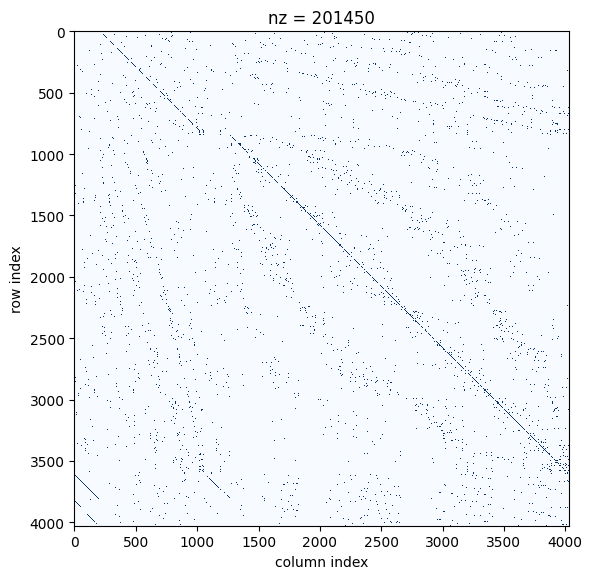

In [15]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.sparse as sp

def spy_like_matlab(A):
    import copy
    if sp.issparse(A):
        A = A.tocsr()
        M, N = A.shape
        img = np.zeros((M, N), dtype=np.uint8)
        img[A.nonzero()] = 1
    else:
        img = (A != 0).astype(np.uint8)

    my_cmap = copy.copy(plt.cm.Blues) # or plt.cm.plasma
    my_cmap.set_bad(color='white')
    plt.figure(figsize=(6,6))
    plt.imshow(img, cmap=my_cmap, origin='upper', interpolation='nearest')
    plt.xlabel('column index')
    plt.ylabel('row index')
    plt.title(f'nz = {img.sum()}')
    plt.tight_layout()
    plt.savefig('L.eps', bbox_inches='tight')
    plt.show()
spy_like_matlab(L)

In [ ]:
for name, param in Phi.named_parameters():
    print(name, param.data)

input_layer.weight tensor([[ 0.2842],
        [-0.2967],
        [-0.1604],
        [-0.2334],
        [-0.5244],
        [-0.0046],
        [-0.2725],
        [ 0.2287],
        [-0.2161],
        [-0.0757],
        [-0.0685],
        [ 0.0640],
        [ 0.3066],
        [ 0.3625],
        [-0.0834],
        [ 0.0658],
        [ 0.3209],
        [-0.0518],
        [-0.1160],
        [-0.0907],
        [ 0.1197],
        [ 0.0820],
        [-0.0369],
        [ 0.0720],
        [ 0.0468],
        [-0.0157],
        [-0.4444],
        [ 0.1845],
        [-0.0036],
        [ 0.0795],
        [-0.2547],
        [ 0.3697],
        [-0.0387],
        [-0.0531],
        [ 0.0157],
        [-0.1510],
        [ 0.3340],
        [-0.0718],
        [ 0.1586],
        [-0.2193],
        [ 0.1426],
        [-0.0696],
        [ 0.3045],
        [ 0.1889],
        [-0.2389],
        [ 0.2154],
        [-0.2263],
        [-0.0997],
        [ 0.0391],
        [-0.2642]], device='cuda:1', dtype=torch.f

In [ ]:
# key = 100
# np.random.seed(key)
# from scipy.io import savemat
# NN = [15, 30, 65, 100,145]

# for qi, n_local in enumerate(NN):
#     print(f'Run Q={qi+1}, N_local_per_patch={n_local}')
#     N_patch_grid = 5
#     N_local_per_patch = n_local
#     N_boundary = n_local
#     R_ptch = 0.8
#     mode = "c-rbf-pum"
#     # generate points
#     X_inner, X_boundary, _, _ ,_ = generator_points_star(
#     N_patch_grid, N_local_per_patch, N_boundary, R_ptch, mode)
#     M1 = X_inner.shape[0]
#     # assemble X,Y
#     X = np.vstack([X_inner, X_boundary])
#     index_in = np.linspace(0,M1-1,M1)
#     index_bc = np.linspace(M1,X.shape[0]-1,X.shape[0]-M1)
#     print(f"X.shape",X.shape[0])
#     savemat(
#     f"./data_poisson/mesh_data_{X.shape[0]}.mat",
#     {
#         "p": X, "index_in": index_in + 1, "index_bc": index_bc + 1,

#     })


Run Q=1, N_local_per_patch=15
X.shape 136
Run Q=2, N_local_per_patch=30
X.shape 274
Run Q=3, N_local_per_patch=65
X.shape 598
Run Q=4, N_local_per_patch=100
X.shape 914
Run Q=5, N_local_per_patch=145
X.shape 1320
